## Setup

In [341]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [342]:
import csv
import pickle
import random
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

In [72]:
PROJECT_DIR = Path('.').resolve()
DATA_DIR = Path('/home/HDD6TB/datasets/emotions/ABAW/ABAW_11/MTL/')

TRAIN_ANNOTATIONS = DATA_DIR / 'training_set_annotations.txt'
VAL_ANNOTATIONS = DATA_DIR / 'validation_set_annotations.txt'
TEST_ANNOTATIONS = DATA_DIR / 'MTL_Challenge_test_set_release.txt'

IMAGE_ROOT = DATA_DIR / 'cropped_aligned'
TEST_IMAGE_ROOT = DATA_DIR / 'test_data' / 'cropped_aligned'

NUM_EXPR_CLASSES = 8
NUM_AUS = 12

EXPR_CLASSES = {
    0: 'Angry',
    1: 'Contempt',
    2: 'Disgust',
    3: 'Fear',
    4: 'Happy',
    5: 'Neutral',
    6: 'Sad',
    7: 'Surprise',
}

AU_NAMES = [
    'AU01', 'AU02', 'AU04', 'AU06', 'AU07',
    'AU10', 'AU12', 'AU15', 'AU23', 'AU24',
    'AU25', 'AU26',
]

VA_MISSING = -5.0
EXPR_MISSING = -1
AU_MISSING = -1

In [73]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## EDA

In [32]:
def load_annotations(path):
    rows = []
    with open(path, newline='') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            image = row[0]
            valence = float(row[1])
            arousal = float(row[2])
            expression = int(row[3])
            aus = list(map(int, row[4:4 + NUM_AUS]))
            rows.append({
                'image': image,
                'video': image.split('/')[0],
                'valence': valence,
                'arousal': arousal,
                'expression': expression,
                'aus': aus,
                'mask_va': valence > VA_MISSING and arousal > VA_MISSING,
                'mask_expr': expression > EXPR_MISSING,
                'mask_aus': min(aus) > AU_MISSING,
            })
    return pd.DataFrame(rows)

In [33]:
train_df = load_annotations(TRAIN_ANNOTATIONS)
val_df = load_annotations(VAL_ANNOTATIONS)

train_df.shape, val_df.shape

((142382, 9), (26876, 9))

In [34]:
train_df

,image,video,valence,arousal,expression,aus,mask_va,mask_expr,mask_aus
0,426/00001.jpg,426,0.00,0.05,0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",True,True,True
1,426/00003.jpg,426,0.00,0.08,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]",True,True,True
2,426/00007.jpg,426,0.00,0.12,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]",True,True,True
3,426/00050.jpg,426,0.00,0.16,-1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]",True,False,True
4,426/00060.jpg,426,0.00,0.16,4,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0]",True,True,True
...,...,...,...,...,...,...,...,...,...
142377,video48/02518.jpg,video48,-5.00,-5.00,4,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]",False,True,False
142378,video48/02522.jpg,video48,-5.00,-5.00,4,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]",False,True,False
142379,video48/02526.jpg,video48,-5.00,-5.00,4,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]",False,True,False
142380,video48/02530.jpg,video48,-5.00,-5.00,4,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]",False,True,False


In [24]:
def split_summary(name, df):
    n = len(df)
    return {
        'split': name,
        'rows': n,
        'videos': df['video'].nunique(),
        'duplicate_images': df['image'].duplicated().sum(),
        'va_labeled': df['mask_va'].sum(),
        'expr_labeled': df['mask_expr'].sum(),
        'aus_labeled': df['mask_aus'].sum(),
        'va_labeled_percent': df['mask_va'].sum()/n,
        'expr_labeled_percent': df['mask_expr'].sum()/n,
        'aus_labeled_percent': df['mask_aus'].sum()/n,
    }

summary_df = pd.DataFrame([
    split_summary('train', train_df),
    split_summary('val', val_df),
]).set_index('split')

pd.set_option('display.float_format', '{:.2f}'.format)
summary_df

,rows,videos,duplicate_images,va_labeled,expr_labeled,aus_labeled,va_labeled_percent,expr_labeled_percent,aus_labeled_percent
split,,,,,,,,,
train,142382,257,951,103917,90645,103316,0.73,0.64,0.73
val,26876,50,210,26876,15440,26876,1.00,0.57,1.00


In [38]:
def expr_class_counts(df):
    subset = df.loc[df['mask_expr'], 'expression']
    counts = subset.value_counts().reindex(range(NUM_EXPR_CLASSES), fill_value=0)
    labels = [EXPR_CLASSES[i] for i in range(NUM_EXPR_CLASSES)]
    return pd.Series(counts.values, index=labels)

def expr_class_rates(df):
    counts = expr_class_counts(df)
    total = counts.sum()
    if total == 0:
        return counts * 0.0
    return counts / total

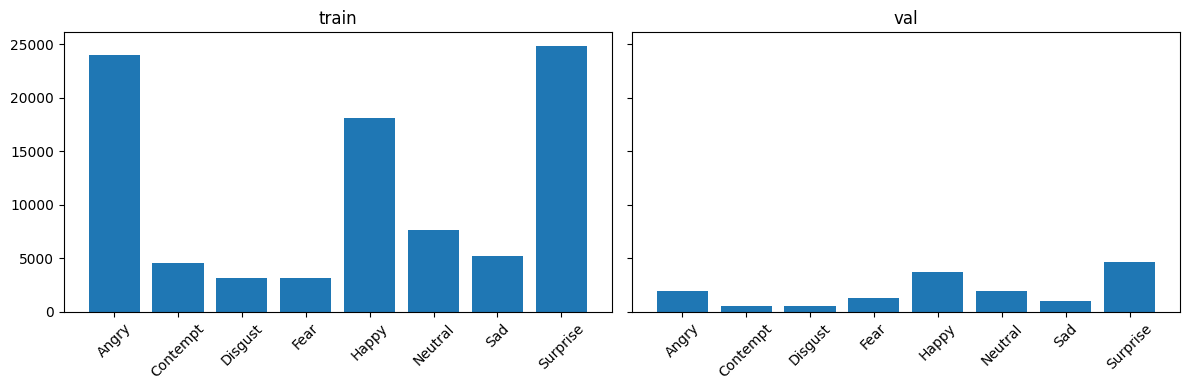

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, df, title in zip(axes, [train_df, val_df], ['train', 'val']):
    counts = expr_class_counts(df)
    ax.bar(counts.index, counts.values)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [40]:
expr_train = expr_class_rates(train_df)
expr_val = expr_class_rates(val_df)

pd.DataFrame({'train': expr_train, 'val': expr_val})

,train,val
Angry,0.26,0.12
Contempt,0.05,0.03
Disgust,0.03,0.04
Fear,0.03,0.08
Happy,0.20,0.24
Neutral,0.08,0.12
Sad,0.06,0.06
Surprise,0.27,0.30


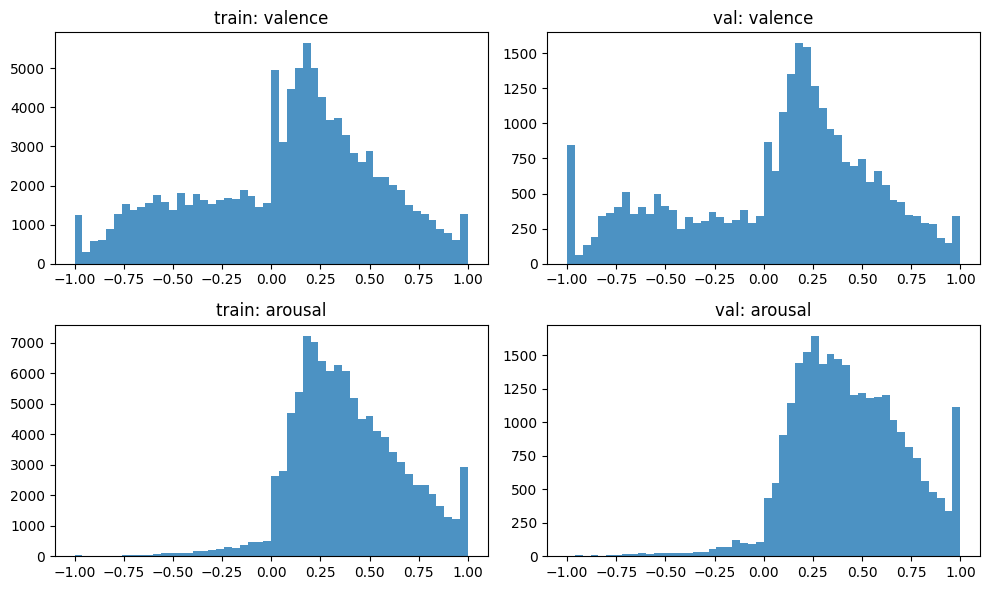

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, df, split in zip(axes[0], [train_df, val_df], ['train', 'val']):
    subset = df.loc[df['mask_va']]
    ax.hist(subset['valence'], bins=50, alpha=0.8)
    ax.set_title(f'{split}: valence')

for ax, df, split in zip(axes[1], [train_df, val_df], ['train', 'val']):
    subset = df.loc[df['mask_va']]
    ax.hist(subset['arousal'], bins=50, alpha=0.8)
    ax.set_title(f'{split}: arousal')

plt.tight_layout()
plt.show()

In [42]:
def au_positive_rates(df):
    """ Оценка дисбалланса AU """
    subset = df.loc[df['mask_aus'], 'aus'].tolist()
    if not subset:
        return pd.Series([0.0] * NUM_AUS, index=AU_NAMES)
    au_array = np.array(subset)
    return pd.Series(au_array.mean(axis=0), index=AU_NAMES)

au_train = au_positive_rates(train_df)
au_val = au_positive_rates(val_df)

pd.DataFrame({'train': au_train, 'val': au_val})

,train,val
AU01,0.18,0.21
AU02,0.08,0.10
AU04,0.20,0.20
AU06,0.30,0.33
AU07,0.40,0.49
AU10,0.37,0.42
AU12,0.26,0.31
AU15,0.02,0.03
AU23,0.03,0.03
AU24,0.05,0.03


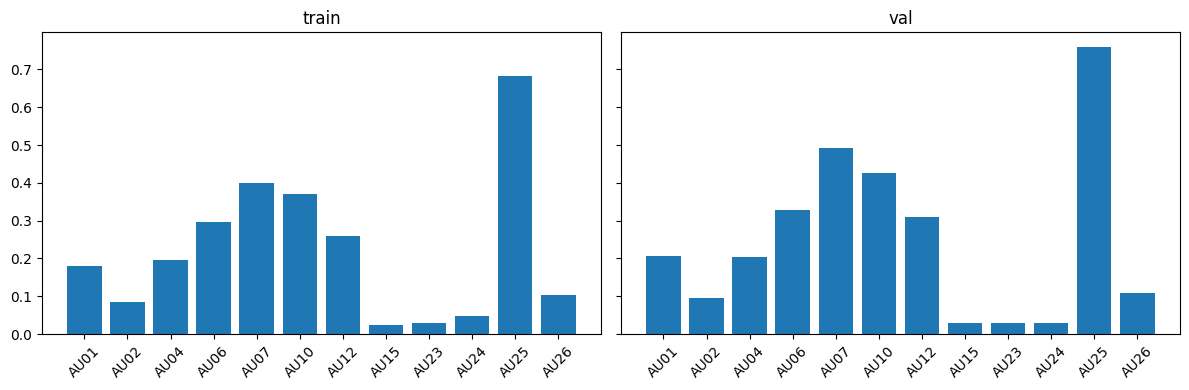

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, df, title in zip(axes, [train_df, val_df], ['train', 'val']):
    rates = au_positive_rates(df)
    ax.bar(AU_NAMES, rates.values)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Dataset

In [47]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [48]:
class MTLDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        mask = df['mask_va'] | df['mask_expr'] | df['mask_aus']
        self.df = df.loc[mask].reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.image_root / row['image']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)

        valence = float(row['valence']) if row['mask_va'] else 0.0
        arousal = float(row['arousal']) if row['mask_va'] else 0.0
        expression = int(row['expression']) if row['mask_expr'] else 0
        aus = row['aus'] if row['mask_aus'] else [0] * NUM_AUS

        return {
            'image': image,
            'valence': torch.tensor(valence, dtype=torch.float32),
            'arousal': torch.tensor(arousal, dtype=torch.float32),
            'expression': torch.tensor(expression, dtype=torch.long),
            'aus': torch.tensor(aus, dtype=torch.float32),
            'mask_va': torch.tensor(row['mask_va'], dtype=torch.float32),
            'mask_expr': torch.tensor(row['mask_expr'], dtype=torch.float32),
            'mask_aus': torch.tensor(row['mask_aus'], dtype=torch.float32),
        }

In [49]:
train_dataset = MTLDataset(train_df, IMAGE_ROOT, transform=train_transform)
val_dataset = MTLDataset(val_df, IMAGE_ROOT, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

len(train_dataset), len(val_dataset)

(142333, 26876)

In [50]:
batch = next(iter(train_loader))

{
    key: value.shape if torch.is_tensor(value) else value
    for key, value in batch.items()
}

{'image': torch.Size([32, 3, 224, 224]),
 'valence': torch.Size([32]),
 'arousal': torch.Size([32]),
 'expression': torch.Size([32]),
 'aus': torch.Size([32, 12]),
 'mask_va': torch.Size([32]),
 'mask_expr': torch.Size([32]),
 'mask_aus': torch.Size([32])}

## Metrics & Losses

In [51]:
def concordance_correlation_coefficient(y_true, y_pred):
    """ Функция для расчета коэффициента соответствия Линна """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mean_true = y_true.mean()
    mean_pred = y_pred.mean()
    var_true = y_true.var()
    var_pred = y_pred.var()
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)


def compute_competition_metrics(valence_true, arousal_true, va_pred,
    expr_true, expr_pred, aus_true, aus_pred, mask_va, mask_expr, mask_aus):
    """ Функция для расчета метрики соревновоания """
    
    mask_va = mask_va.astype(bool)
    mask_expr = mask_expr.astype(bool)
    mask_aus = mask_aus.astype(bool)

    ccc_v = concordance_correlation_coefficient(valence_true[mask_va], va_pred[mask_va, 0])
    ccc_a = concordance_correlation_coefficient(arousal_true[mask_va], va_pred[mask_va, 1])
    ccc_va = 0.5 * (ccc_v + ccc_a)

    f1_expr = f1_score(expr_true[mask_expr], expr_pred[mask_expr], average='macro')

    aus_true = aus_true[mask_aus]
    aus_pred = (aus_pred[mask_aus] >= 0.5).astype(np.int32)
    f1_per_au = [f1_score(aus_true[:, i], aus_pred[:, i]) for i in range(NUM_AUS)]
    f1_au = float(np.mean(f1_per_au))

    p_score = ccc_va + f1_expr + f1_au

    return {
        'ccc_v': ccc_v,
        'ccc_a': ccc_a,
        'ccc_va': ccc_va,
        'f1_expr': f1_expr,
        'f1_au': f1_au,
        'f1_per_au': f1_per_au,
        'p_score': p_score,
    }

In [52]:
def ccc_torch(y_true, y_pred):
    """ Функция для расчета коэффициента соответствия Линна для PyTorch """
    mean_true = torch.mean(y_true)
    mean_pred = torch.mean(y_pred)
    var_true = torch.var(y_true, unbiased=False)
    var_pred = torch.var(y_pred, unbiased=False)
    cov = torch.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)


def va_loss(va_pred, valence, arousal, mask_va):
    """ Функция потерь valence, arousal """
    mask = mask_va > 0
    if mask.sum() == 0:
        return va_pred.sum() * 0.0
    pred = va_pred[mask]
    true_v = valence[mask]
    true_a = arousal[mask]
    ccc_v = ccc_torch(true_v, pred[:, 0])
    ccc_a = ccc_torch(true_a, pred[:, 1])
    return 1 - 0.5 * (ccc_v + ccc_a)


def expr_loss(expr_logits, expression, mask_expr, class_weight=None):
    """ Функция потерь expression """
    mask = mask_expr > 0
    if mask.sum() == 0:
        return expr_logits.sum() * 0.0
    return F.cross_entropy(expr_logits[mask], expression[mask], weight=class_weight)


def au_loss(aus_pred, aus_true, mask_aus):
    """ Функция потерь AUS """
    mask = mask_aus > 0
    if mask.sum() == 0:
        return aus_pred.sum() * 0.0
    return F.binary_cross_entropy(aus_pred[mask], aus_true[mask])


def mtl_loss(va_pred, expr_logits, aus_pred,
    valence, arousal, expression, aus_true,
    mask_va, mask_expr, mask_aus,
    expr_class_weight=None, w_va=1.0, w_expr=1.0, w_au=1.0):
    """ Функция потерь """
    
    loss_v = va_loss(va_pred, valence, arousal, mask_va)
    loss_e = expr_loss(expr_logits, expression, mask_expr, expr_class_weight)
    loss_a = au_loss(aus_pred, aus_true, mask_aus)
    total = w_va * loss_v + w_expr * loss_e + w_au * loss_a
    return total, {
        'loss_va': loss_v.item(),
        'loss_expr': loss_e.item(),
        'loss_au': loss_a.item(),
        'loss_total': total.item(),
    }

In [53]:
expr_counts = expr_class_counts(train_df)
expr_weights = expr_counts.sum() / (NUM_EXPR_CLASSES * expr_counts)
expr_class_weight = torch.tensor(expr_weights.values, dtype=torch.float32, device=DEVICE)

expr_class_weight

tensor([0.4726, 2.4875, 3.5766, 3.6293, 0.6248, 1.4891, 2.1673, 0.4559],
       device='cuda:0')

In [54]:
batch = next(iter(val_loader))

with torch.no_grad():
    va_pred = torch.tanh(torch.randn(len(batch['image']), 2, device=DEVICE))
    expr_logits = torch.randn(len(batch['image']), NUM_EXPR_CLASSES, device=DEVICE)
    aus_pred = torch.sigmoid(torch.randn(len(batch['image']), NUM_AUS, device=DEVICE))

    loss, loss_parts = mtl_loss(
        va_pred, expr_logits, aus_pred,
        batch['valence'].to(DEVICE),
        batch['arousal'].to(DEVICE),
        batch['expression'].to(DEVICE),
        batch['aus'].to(DEVICE),
        batch['mask_va'].to(DEVICE),
        batch['mask_expr'].to(DEVICE),
        batch['mask_aus'].to(DEVICE),
        expr_class_weight=expr_class_weight,
    )

    metrics = compute_competition_metrics(
        batch['valence'].numpy(),
        batch['arousal'].numpy(),
        va_pred.cpu().numpy(),
        batch['expression'].numpy(),
        expr_logits.argmax(dim=1).cpu().numpy(),
        batch['aus'].numpy(),
        aus_pred.cpu().numpy(),
        batch['mask_va'].numpy(),
        batch['mask_expr'].numpy(),
        batch['mask_aus'].numpy(),
    )

loss_parts, {k: round(v, 4) for k, v in metrics.items() if k != 'f1_per_au'}

({'loss_va': 1.0038281679153442,
  'loss_expr': 2.2743828296661377,
  'loss_au': 0.8197050094604492,
  'loss_total': 4.097916126251221},
 {'ccc_v': 0.045,
  'ccc_a': -0.0527,
  'ccc_va': -0.0038,
  'f1_expr': 0.0238,
  'f1_au': 0.1187,
  'p_score': 0.1387})

# Baseline Model

### Model

In [55]:
BACKBONE_NAME = 'convnext_base'
FREEZE_BACKBONE = True

In [56]:
class MTLModel(nn.Module):
    def __init__(
        self,
        backbone_name=BACKBONE_NAME,
        num_expr=NUM_EXPR_CLASSES,
        num_aus=NUM_AUS,
        freeze_backbone=FREEZE_BACKBONE,
    ):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.head_va = nn.Linear(feat_dim, 2)
        self.head_expr = nn.Linear(feat_dim, num_expr)
        self.head_au = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_aus),
        )

    def forward(self, x):
        features = self.backbone(x)
        va_pred = torch.tanh(self.head_va(features))
        expr_logits = self.head_expr(features)
        aus_pred = torch.sigmoid(self.head_au(features))
        return va_pred, expr_logits, aus_pred

In [57]:
model = MTLModel().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

trainable, total

(142998, 87709462)

In [58]:
model.eval()
with torch.no_grad():
    images = batch['image'].to(DEVICE)
    va_pred, expr_logits, aus_pred = model(images)

{
    'va_pred': va_pred.shape,
    'expr_logits': expr_logits.shape,
    'aus_pred': aus_pred.shape,
}

{'va_pred': torch.Size([32, 2]),
 'expr_logits': torch.Size([32, 8]),
 'aus_pred': torch.Size([32, 12])}

### Training

In [63]:
EPOCHS = 1
LR = 1e-3

CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)
BEST_CHECKPOINT = CHECKPOINT_DIR / 'best_model.pt'

In [64]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
)

In [65]:
def run_epoch(model, loader, optimizer=None, compute_metrics=True):
    train_mode = optimizer is not None
    model.train(train_mode)

    loss_sum = 0.0
    n_batches = 0

    valence_all, arousal_all, va_pred_all = [], [], []
    expr_all, expr_pred_all = [], []
    aus_all, aus_pred_all = [], []
    mask_va_all, mask_expr_all, mask_aus_all = [], [], []

    for batch in tqdm(loader, leave=False):
        images = batch['image'].to(DEVICE)
        valence = batch['valence'].to(DEVICE)
        arousal = batch['arousal'].to(DEVICE)
        expression = batch['expression'].to(DEVICE)
        aus = batch['aus'].to(DEVICE)
        mask_va = batch['mask_va'].to(DEVICE)
        mask_expr = batch['mask_expr'].to(DEVICE)
        mask_aus = batch['mask_aus'].to(DEVICE)

        with torch.set_grad_enabled(train_mode):
            va_pred, expr_logits, aus_pred = model(images)
            loss, loss_parts = mtl_loss(
                va_pred, expr_logits, aus_pred,
                valence, arousal, expression, aus,
                mask_va, mask_expr, mask_aus,
                expr_class_weight=expr_class_weight,
            )

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        loss_sum += loss_parts['loss_total']
        n_batches += 1

        if compute_metrics:
            valence_all.append(valence.cpu().numpy())
            arousal_all.append(arousal.cpu().numpy())
            va_pred_all.append(va_pred.detach().cpu().numpy())
            expr_all.append(expression.cpu().numpy())
            expr_pred_all.append(expr_logits.argmax(dim=1).cpu().numpy())
            aus_all.append(aus.cpu().numpy())
            aus_pred_all.append(aus_pred.detach().cpu().numpy())
            mask_va_all.append(mask_va.cpu().numpy())
            mask_expr_all.append(mask_expr.cpu().numpy())
            mask_aus_all.append(mask_aus.cpu().numpy())

    result = {'loss': loss_sum / max(n_batches, 1)}

    if compute_metrics:
        metrics = compute_competition_metrics(
            np.concatenate(valence_all),
            np.concatenate(arousal_all),
            np.concatenate(va_pred_all),
            np.concatenate(expr_all),
            np.concatenate(expr_pred_all),
            np.concatenate(aus_all),
            np.concatenate(aus_pred_all),
            np.concatenate(mask_va_all),
            np.concatenate(mask_expr_all),
            np.concatenate(mask_aus_all),
        )
        result.update(metrics)

    return result

In [66]:
history = []
best_p_score = -float('inf')

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, compute_metrics=False)
    val_metrics = run_epoch(model, val_loader, compute_metrics=True)

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'val_loss': val_metrics['loss'],
        'ccc_va': val_metrics['ccc_va'],
        'f1_expr': val_metrics['f1_expr'],
        'f1_au': val_metrics['f1_au'],
        'p_score': val_metrics['p_score'],
    }
    history.append(row)

    if val_metrics['p_score'] > best_p_score:
        best_p_score = val_metrics['p_score']
        torch.save(model.state_dict(), BEST_CHECKPOINT)

    print(
        f"epoch {epoch:02d} | "
        f"train_loss {row['train_loss']:.4f} | "
        f"val_loss {row['val_loss']:.4f} | "
        f"P {row['p_score']:.4f} "
        f"(ccc {row['ccc_va']:.4f}, expr {row['f1_expr']:.4f}, au {row['f1_au']:.4f})"
    )

history_df = pd.DataFrame(history)
history_df

  0%|          | 0/4448 [00:00<?, ?it/s]

  0%|          | 0/840 [00:00<?, ?it/s]

epoch 01 | train_loss 1.3869 | val_loss 3.4058 | P 0.8526 (ccc 0.2248, expr 0.2738, au 0.3540)


,epoch,train_loss,val_loss,ccc_va,f1_expr,f1_au,p_score
0,1,1.39,3.41,0.22,0.27,0.35,0.85


### Evaluation

In [135]:
OFFICIAL_BASELINE_P = 0.45

baseline_summary = pd.DataFrame([
    {
        'model': 'official baseline',
        'ccc_va': np.nan,
        'f1_expr': np.nan,
        'f1_au': np.nan,
        'p_score': OFFICIAL_BASELINE_P,
    },
    {
        'model': 'convnext baseline',
        'ccc_va': history_df.iloc[-1]['ccc_va'],
        'f1_expr': history_df.iloc[-1]['f1_expr'],
        'f1_au': history_df.iloc[-1]['f1_au'],
        'p_score': history_df.iloc[-1]['p_score'],
    },

])

baseline_summary

,model,ccc_va,f1_expr,f1_au,p_score
0,official baseline,NaN,NaN,NaN,0.45
1,convnext baseline,0.22,0.27,0.35,0.85


# DDAMFN

## Feature extraction

In [208]:
DDAMFN_PATH = Path('/home/avsavchenko/src/distr/DDAMFN')
INSIGHTFACE_PATH = Path('/home/avsavchenko/src/distr/insightface/recognition/arcface_torch/backbones')

EXTRACTOR_NAME = 'ddamfnet_8_mtl'
EXTRACTOR_CHECKPOINT = 'affectnet8_epoch9_acc0.642_mtl_2'
FEATURES_SUFFIX = '_aligned'
BATCH_SIZE_EXTRACT = 48

FEATURES_DIR = PROJECT_DIR / 'features'
FEATURES_DIR.mkdir(exist_ok=True)

In [79]:
sys.path.insert(0, str(DDAMFN_PATH))
from networks.DDAM import DDAMNet

model = DDAMNet(num_class=10, num_head=2, pretrained=False)
state = torch.load(
    DDAMFN_PATH / 'checkpoints' / f'{EXTRACTOR_CHECKPOINT}.pth',
    map_location='cpu',
    weights_only=False,
)
model.load_state_dict(state['model_state_dict'])

classifier_weights = model.fc.weight.detach().cpu().numpy()
classifier_bias = model.fc.bias.detach().cpu().numpy()

model.bn = nn.Identity()
model.fc = nn.Identity()
feature_extractor = model.to(DEVICE).eval()

classifier_weights.shape, classifier_bias.shape

((10, 512), (10,))

In [81]:
feat_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [80]:
def extract_features(image_paths, image_root, model, transform, classifier_weights, classifier_bias, batch_size=BATCH_SIZE_EXTRACT):
    """ Получение эмбединга фотографий """
    filename2features = {}
    batch_tensors = []
    batch_names = []

    def flush_batch():
        nonlocal batch_tensors, batch_names
        if not batch_tensors:
            return
        with torch.no_grad():
            outputs = model(torch.stack(batch_tensors).to(DEVICE))
            features = outputs[0].cpu().numpy() if isinstance(outputs, tuple) else outputs.cpu().numpy()
        scores = features @ classifier_weights.T + classifier_bias
        for name, feat, score in zip(batch_names, features, scores):
            filename2features[name] = (feat.astype(np.float32), score.astype(np.float32))
        batch_tensors = []
        batch_names = []

    for image_path in tqdm(image_paths, desc='extract'):
        img = Image.open(Path(image_root) / image_path).convert('RGB')
        batch_tensors.append(transform(img))
        batch_names.append(image_path)
        if len(batch_tensors) >= batch_size:
            flush_batch()

    flush_batch()
    return filename2features

In [ ]:
train_val_images = pd.concat([train_df['image'], val_df['image']]).drop_duplicates().tolist()

filename2features_all = extract_features(
    train_val_images,
    IMAGE_ROOT,
    feature_extractor,
    feat_transform,
    classifier_weights,
    classifier_bias,
)

MODEL2FEATURES = FEATURES_DIR / f'{EXTRACTOR_NAME}{FEATURES_SUFFIX}.pickle'
with open(MODEL2FEATURES, 'wb') as f:
    pickle.dump(filename2features_all, f, protocol=pickle.HIGHEST_PROTOCOL)

len(filename2features_all), MODEL2FEATURES

extract:   0%|          | 0/168097 [00:00<?, ?it/s]

In [84]:
with open(TEST_ANNOTATIONS) as f:
    test_images = [line.strip() for line in f.readlines()[1:] if line.strip()]

filename2features_test = extract_features(
    test_images,
    TEST_IMAGE_ROOT,
    feature_extractor,
    feat_transform,
    classifier_weights,
    classifier_bias,
)

MODEL2FEATURES_TEST = FEATURES_DIR / f'{EXTRACTOR_NAME}{FEATURES_SUFFIX}_test.pickle'
with open(MODEL2FEATURES_TEST, 'wb') as f:
    pickle.dump(filename2features_test, f, protocol=pickle.HIGHEST_PROTOCOL)

len(filename2features_test), MODEL2FEATURES_TEST

extract:   0%|          | 0/51159 [00:00<?, ?it/s]

(50441,
 PosixPath('/home/hse_student/a.bakin/MTL/features/ddamfnet_8_mtl_aligned_test.pickle'))

In [85]:
sample_name = next(iter(filename2features_all))
feat, score = filename2features_all[sample_name]
sample_name, feat.shape, score.shape

('426/00001.jpg', (512,), (10,))

In [86]:
sample_name = next(iter(filename2features_test))
feat, score = filename2features_test[sample_name]
sample_name, feat.shape, score.shape

('video45_1/00001.jpg', (512,), (10,))

## Feature dataset

In [88]:
if False:
    with open(MODEL2FEATURES, 'rb') as f:
        filename2features_all = pickle.load(f)

FEATURES_ONLY, SCORES_ONLY, FEATURES_SCORES = 0, 1, 2
FEATURES_SCORES_AGGREGATION = FEATURES_SCORES
SCORES_LEN = 10

In [89]:
def get_image2all(filename, filename2features):
    """ Читает CSV-аннотации и собирает из них единый датасет для MTL: признаки + метки + маски """
    global SCORES_LEN
    with open(filename) as f:
        lines = f.read().splitlines()

    num_missed = 0
    X, y_va, y_expr, y_aus = [], [], [], []
    masks_va, masks_expr, masks_aus = [], [], []
    videoname_frames = []

    for line in lines[1:]:
        row = line.split(',')
        imagename = row[0]
        valence = float(row[1])
        arousal = float(row[2])
        expression = int(row[3])
        aus = list(map(int, row[4:4 + NUM_AUS]))

        mask_va = valence > VA_MISSING and arousal > VA_MISSING
        if not mask_va:
            valence = arousal = 0.0

        mask_expr = expression > EXPR_MISSING
        if not mask_expr:
            expression = 0

        mask_aus = min(aus) > AU_MISSING
        if not mask_aus:
            aus = [0] * NUM_AUS

        if mask_va or mask_expr or mask_aus:
            if imagename in filename2features:
                video, frame_name = imagename.split('/')
                frame_ind = int(frame_name.replace('.jpg', ''))
                videoname_frames.append((video, frame_ind))

                feats, scores = filename2features[imagename]
                SCORES_LEN = len(scores)
                if FEATURES_SCORES_AGGREGATION == FEATURES_ONLY:
                    X.append(feats)
                elif FEATURES_SCORES_AGGREGATION == SCORES_ONLY:
                    X.append(scores)
                else:
                    X.append(np.concatenate((feats, scores)))

                y_va.append((valence, arousal))
                masks_va.append(mask_va)
                y_expr.append(expression)
                masks_expr.append(mask_expr)
                y_aus.append(aus)
                masks_aus.append(mask_aus)
            else:
                num_missed += 1

    X = np.array(X, dtype=np.float32)
    y_va = np.array(y_va, dtype=np.float32)
    y_expr = np.array(y_expr, dtype=np.int64)
    y_aus = np.array(y_aus, dtype=np.float32)
    masks_va = np.array(masks_va, dtype=np.float32)
    masks_expr = np.array(masks_expr, dtype=np.float32)
    masks_aus = np.array(masks_aus, dtype=np.float32)
    print(f'{Path(filename).name}: X {X.shape}, missed {num_missed}')
    return X, y_va, y_expr, y_aus, masks_va, masks_expr, masks_aus, videoname_frames

X_train, y_va_train, y_expr_train, y_aus_train, m_va_train, m_expr_train, m_aus_train, _ = get_image2all(
    TRAIN_ANNOTATIONS, filename2features_all
)
X_val, y_va_val, y_expr_val, y_aus_val, m_va_val, m_expr_val, m_aus_val, videoname_frames_val = get_image2all(
    VAL_ANNOTATIONS, filename2features_all
)

SCORES_LEN

training_set_annotations.txt: X (142333, 522), missed 0
validation_set_annotations.txt: X (26876, 522), missed 0


10

In [93]:
y_aus_train.shape

(142333, 12)

In [90]:
# Получение весов AU для обучения
num_aus = y_aus_train.shape[1]
aus_class_weights = np.empty((num_aus, 2), dtype=np.float32)
for i in range(num_aus):
    mask = m_aus_train == 1
    neg = np.sum(y_aus_train[mask, i] == 0)
    pos = np.sum(y_aus_train[mask, i] == 1)
    total = neg + pos
    aus_class_weights[i, 0] = (1.0 / neg) * (total / 2.0) if neg > 0 else 0.0
    aus_class_weights[i, 1] = (1.0 / pos) * (total / 2.0) if pos > 0 else 0.0

aus_class_weights = torch.tensor(aus_class_weights, dtype=torch.float32)

In [91]:
aus_class_weights

tensor([[ 0.6106,  2.7605],
        [ 0.5462,  5.9071],
        [ 0.6226,  2.5395],
        [ 0.7105,  1.6879],
        [ 0.8335,  1.2497],
        [ 0.7944,  1.3493],
        [ 0.6750,  1.9288],
        [ 0.5122, 20.9992],
        [ 0.5149, 17.3349],
        [ 0.5254, 10.3254],
        [ 1.5782,  0.7319],
        [ 0.5581,  4.8027]])

## MTL heads

### Model

In [112]:
class MTLHeads(nn.Module):
    def __init__(self, input_dim, scores_len=SCORES_LEN, num_expr=NUM_EXPR_CLASSES, num_aus=NUM_AUS):
        super().__init__()
        self.scores_len = scores_len
        self.head_expr = nn.Linear(input_dim, num_expr)
        self.head_va = nn.Linear(scores_len, 2)
        self.head_au = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_aus),
        )

    def forward(self, x):
        expr_logits = self.head_expr(x)
        va_pred = torch.tanh(self.head_va(x[:, -self.scores_len:]))
        aus_pred = torch.sigmoid(self.head_au(x))
        return va_pred, expr_logits, aus_pred


class FeatureDataset(Dataset):
    def __init__(self, X, y_va, y_expr, y_aus, m_va, m_expr, m_aus):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_va = torch.tensor(y_va, dtype=torch.float32)
        self.y_expr = torch.tensor(y_expr, dtype=torch.long)
        self.y_aus = torch.tensor(y_aus, dtype=torch.float32)
        self.m_va = torch.tensor(m_va, dtype=torch.float32)
        self.m_expr = torch.tensor(m_expr, dtype=torch.float32)
        self.m_aus = torch.tensor(m_aus, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y_va[idx],
            self.y_expr[idx],
            self.y_aus[idx],
            self.m_va[idx],
            self.m_expr[idx],
            self.m_aus[idx],
        )

In [113]:
MTL_BATCH_SIZE = 512
MTL_LR = 1e-3
MTL_CHECKPOINT = CHECKPOINT_DIR / f'{EXTRACTOR_NAME}{FEATURES_SUFFIX}_heads.pt'

TRAIN = (
    X_train, y_va_train, y_expr_train, y_aus_train,
    m_va_train, m_expr_train, m_aus_train,
)
VAL = (
    X_val, y_va_val, y_expr_val, y_aus_val,
    m_va_val, m_expr_val, m_aus_val,
)


def subset_by_mask(arrays, mask):
    mask = mask.astype(bool)
    X, y_va, y_expr, y_aus, m_va, m_expr, m_aus = arrays
    return (X[mask], y_va[mask], y_expr[mask], y_aus[mask], m_va[mask], m_expr[mask], m_aus[mask])

def make_feat_loader(arrays, shuffle):
    return DataLoader(
        FeatureDataset(*arrays),
        batch_size=MTL_BATCH_SIZE,
        shuffle=shuffle,
    )

def make_task_loaders(train_arrays, val_arrays, train_mask, val_mask):
    return (
        make_feat_loader(subset_by_mask(train_arrays, train_mask), shuffle=True),
        make_feat_loader(subset_by_mask(val_arrays, val_mask), shuffle=False),
    )


train_feat_loader = make_feat_loader(TRAIN, shuffle=True)
val_feat_loader = make_feat_loader(VAL, shuffle=False)

train_expr_loader, val_expr_loader = make_task_loaders(TRAIN, VAL, m_expr_train == 1, m_expr_val == 1)
train_va_loader, val_va_loader = make_task_loaders(TRAIN, VAL, m_va_train == 1, m_va_val == 1)
train_au_loader, val_au_loader = make_task_loaders(TRAIN, VAL, m_aus_train == 1, m_aus_val == 1)

pd.DataFrame([
    {'task': 'all',  'train': len(train_feat_loader.dataset), 'val': len(val_feat_loader.dataset)},
    {'task': 'expr', 'train': len(train_expr_loader.dataset), 'val': len(val_expr_loader.dataset)},
    {'task': 'va',   'train': len(train_va_loader.dataset),   'val': len(val_va_loader.dataset)},
    {'task': 'au',   'train': len(train_au_loader.dataset),   'val': len(val_au_loader.dataset)},
])

,task,train,val
0,all,142333,26876
1,expr,90645,15440
2,va,103917,26876
3,au,103316,26876


In [114]:
def au_loss_weighted(aus_pred, aus_true, mask_aus, class_weights):
    """ Расчет взвешенной функции потерь AU """
    mask = mask_aus > 0
    if mask.sum() == 0:
        return aus_pred.sum() * 0.0
    pred = aus_pred[mask]
    true = aus_true[mask]
    w0 = class_weights[:, 0].to(pred.device)
    w1 = class_weights[:, 1].to(pred.device)
    weights = w0 * (1 - true) + w1 * true
    loss = F.binary_cross_entropy(pred, true, reduction='none')
    return (loss * weights).mean()


def predict_features(model, loader):
    """ Расчет метрики соревнования """
    model.eval()
    valence_all, arousal_all, va_pred_all = [], [], []
    expr_all, expr_pred_all = [], []
    aus_all, aus_pred_all = [], []
    mask_va_all, mask_expr_all, mask_aus_all = [], [], []

    with torch.no_grad():
        for X, y_va, y_expr, y_aus, m_va, m_expr, m_aus in loader:
            X = X.to(DEVICE)
            va_pred, expr_logits, aus_pred = model(X)
            expr_pred = expr_logits.argmax(dim=1)

            valence_all.append(y_va[:, 0].numpy())
            arousal_all.append(y_va[:, 1].numpy())
            va_pred_all.append(va_pred.cpu().numpy())
            expr_all.append(y_expr.numpy())
            expr_pred_all.append(expr_pred.cpu().numpy())
            aus_all.append(y_aus.numpy())
            aus_pred_all.append(aus_pred.cpu().numpy())
            mask_va_all.append(m_va.numpy())
            mask_expr_all.append(m_expr.numpy())
            mask_aus_all.append(m_aus.numpy())

    return compute_competition_metrics(
        np.concatenate(valence_all),
        np.concatenate(arousal_all),
        np.concatenate(va_pred_all),
        np.concatenate(expr_all),
        np.concatenate(expr_pred_all),
        np.concatenate(aus_all),
        np.concatenate(aus_pred_all),
        np.concatenate(mask_va_all),
        np.concatenate(mask_expr_all),
        np.concatenate(mask_aus_all),
    )

In [223]:
TASK_VAL_METRIC = {'expr': 'f1_expr', 'va': 'ccc_va', 'au': 'f1_au'}
HEAD_MODULES = lambda model: {'expr': model.head_expr, 'va': model.head_va, 'au': model.head_au}

def task_loss(task, va_pred, expr_logits, aus_pred, y_va, y_expr, y_aus, m_va, m_expr, m_aus):
    if task == 'expr':
        return expr_loss(expr_logits, y_expr, m_expr, expr_class_weight.to(DEVICE))
    if task == 'va':
        return va_loss(va_pred, y_va[:, 0], y_va[:, 1], m_va)
    return au_loss_weighted(aus_pred, y_aus, m_aus, aus_class_weights.to(DEVICE))


def train_mtl_head(model, train_loader, val_loader, task, epochs=10, lr=MTL_LR, val_full_loader=None):
    if val_full_loader is None:
        val_full_loader = val_feat_loader
        
    metric_key = TASK_VAL_METRIC[task]
    optimizer = torch.optim.Adam(
        HEAD_MODULES(model)[task].parameters(),
        lr=lr,
        weight_decay=1.0 / MTL_BATCH_SIZE,
    )

    best_state = deepcopy(model.state_dict())
    best_score = -float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []

        for batch in tqdm(train_loader, leave=False, desc=f'{task} {epoch}/{epochs}'):
            X, y_va, y_expr, y_aus, m_va, m_expr, m_aus = [t.to(DEVICE) for t in batch]
            va_pred, expr_logits, aus_pred = model(X)
            loss = task_loss(task, va_pred, expr_logits, aus_pred, y_va, y_expr, y_aus, m_va, m_expr, m_aus)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        val_task = predict_features(model, val_loader)
        val_full = predict_features(model, val_full_loader)
        score = val_task[metric_key]

        if score > best_score:
            best_score = score
            best_state = deepcopy(model.state_dict())

        print(
            f'{task} epoch {epoch:02d} | loss {np.mean(batch_losses):.4f} | '
            f'val {metric_key} {score:.4f} | best {best_score:.4f} | '
            f'val P {val_full["p_score"]:.4f}'
        )

    model.load_state_dict(best_state)
    print(f'{task}: finished, best val {metric_key} = {best_score:.4f}\n')


### MTL training

In [124]:
mtl_model = MTLHeads(input_dim=X_train.shape[1]).to(DEVICE)
print(mtl_model)

MTLHeads(
  (head_expr): Linear(in_features=522, out_features=8, bias=True)
  (head_va): Linear(in_features=10, out_features=2, bias=True)
  (head_au): Sequential(
    (0): Linear(in_features=522, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


In [125]:
train_mtl_head(mtl_model, train_expr_loader, val_expr_loader, task='expr', epochs=10, lr=1e-4)

expr 1/10:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 01 | loss 1.7130 | val f1_expr 0.2942 | best 0.2942 | val P 0.7001


expr 2/10:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 02 | loss 1.4031 | val f1_expr 0.3020 | best 0.3020 | val P 0.7079


expr 3/10:   0%|          | 0/178 [00:00<?, ?it/s]

...

expr epoch 08 | loss 1.0537 | val f1_expr 0.3248 | best 0.3271 | val P 0.7307


expr 9/10:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 09 | loss 1.0275 | val f1_expr 0.3222 | best 0.3271 | val P 0.7281


expr 10/10:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 10 | loss 1.0008 | val f1_expr 0.3241 | best 0.3271 | val P 0.7300
expr: finished, best val f1_expr = 0.3271



In [126]:
train_mtl_head(mtl_model, train_va_loader, val_va_loader, task='va', epochs=20)

va 1/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 01 | loss 0.7284 | val ccc_va 0.3682 | best 0.3682 | val P 0.9731


va 2/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 02 | loss 0.5680 | val ccc_va 0.4727 | best 0.4727 | val P 1.0776


va 3/20:   0%|          | 0/203 [00:00<?, ?it/s]

...

va epoch 18 | loss 0.5102 | val ccc_va 0.4796 | best 0.4809 | val P 1.0845


va 19/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 19 | loss 0.5102 | val ccc_va 0.4814 | best 0.4814 | val P 1.0864


va 20/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 20 | loss 0.5104 | val ccc_va 0.4793 | best 0.4814 | val P 1.0842
va: finished, best val ccc_va = 0.4814



In [127]:
train_mtl_head(mtl_model, train_au_loader, val_au_loader, task='au', epochs=10)


au 1/10:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 01 | loss 0.4494 | val f1_au 0.4919 | best 0.4919 | val P 1.3005


au 2/10:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 02 | loss 0.3920 | val f1_au 0.4943 | best 0.4943 | val P 1.3028


au 3/10:   0%|          | 0/202 [00:00<?, ?it/s]

...

au epoch 08 | loss 0.3502 | val f1_au 0.4933 | best 0.4973 | val P 1.3018


au 9/10:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 09 | loss 0.3481 | val f1_au 0.5001 | best 0.5001 | val P 1.3086


au 10/10:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 10 | loss 0.3465 | val f1_au 0.4984 | best 0.5001 | val P 1.3069
au: finished, best val f1_au = 0.5001



In [128]:
torch.save(mtl_model.state_dict(), MTL_CHECKPOINT)
mtl_val_metrics = predict_features(mtl_model, val_feat_loader)
mtl_val_metrics

{'ccc_v': 0.49119296465613055,
 'ccc_a': 0.4716749734278017,
 'ccc_va': 0.4814339690419661,
 'f1_expr': 0.32711110612647154,
 'f1_au': 0.5000995147545523,
 'f1_per_au': [0.5984711167152652,
  0.40463948343895734,
  0.5947806596221582,
  0.5928256765261171,
  0.7180126099596028,
  0.7140917254369442,
  0.6898298097874095,
  0.21992535170829744,
  0.10950041931232778,
  0.17073738078622935,
  0.8406870469587141,
  0.34769289680260385],
 'p_score': 1.30864458992299}

## Post-processing

In [155]:
@torch.no_grad()
def predict_val_arrays(model, loader):
    model.eval()
    va_pred_all, expr_logits_all, aus_pred_all, X_all = [], [], [], []
    valence_all, arousal_all, expr_all, aus_all = [], [], [], []
    mask_va_all, mask_expr_all, mask_aus_all = [], [], []

    for X, y_va, y_expr, y_aus, m_va, m_expr, m_aus in loader:
        X_np = X.numpy()
        X = X.to(DEVICE)
        va_pred, expr_logits, aus_pred = model(X)
        va_pred_all.append(va_pred.cpu().numpy())
        expr_logits_all.append(expr_logits.cpu().numpy())
        aus_pred_all.append(aus_pred.cpu().numpy())
        X_all.append(X_np)
        valence_all.append(y_va[:, 0].numpy())
        arousal_all.append(y_va[:, 1].numpy())
        expr_all.append(y_expr.numpy())
        aus_all.append(y_aus.numpy())
        mask_va_all.append(m_va.numpy())
        mask_expr_all.append(m_expr.numpy())
        mask_aus_all.append(m_aus.numpy())

    return {
        'va_pred': np.concatenate(va_pred_all),
        'expr_logits': np.concatenate(expr_logits_all),
        'aus_pred': np.concatenate(aus_pred_all),
        'X': np.concatenate(X_all),
        'valence': np.concatenate(valence_all),
        'arousal': np.concatenate(arousal_all),
        'expr': np.concatenate(expr_all),
        'aus': np.concatenate(aus_all),
        'mask_va': np.concatenate(mask_va_all),
        'mask_expr': np.concatenate(mask_expr_all),
        'mask_aus': np.concatenate(mask_aus_all),
    }

In [156]:
raw_val = predict_val_arrays(mtl_model, val_feat_loader)
print(f"Кадров на val: {len(raw_val['expr'])}")
print(f"  с меткой expression: {raw_val['mask_expr'].sum():.0f}")
print(f"  с меткой VA:         {raw_val['mask_va'].sum():.0f}")
print(f"  с меткой AU:         {raw_val['mask_aus'].sum():.0f}")

Кадров на val: 26876
  с меткой expression: 15440
  с меткой VA:         26876
  с меткой AU:         26876


### Expression (temporal smoothing + ensamble AFFECTNET)

In [269]:
# Соответствие классов AffectNet -> MTL
AFFECTNET2MTL = np.array([5, 0, 2, 3, 4, 6, 7, 1])

In [260]:
def scores2probabs(x):
    """ Softmax """
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)


def affectnet_probs_from_X(X):
    """ 8 AffectNet scores из хвоста признаков, переставленные в порядок MTL """
    scores = X[:, -SCORES_LEN:-2][:, AFFECTNET2MTL]
    return scores2probabs(scores)


def temporal_smooth(values, videoname_frames, sigma=10.0, delta=50):
    """Gaussian-сглаживание по кадрам одного видео (работает для expr logits и VA)."""
    n = len(values)
    smoothed = np.zeros_like(values, dtype=np.float64)
    for i in range(n):
        video_i, frame_i = videoname_frames[i]
        acc = np.zeros(values.shape[1:], dtype=np.float64)
        k_sum = 0.0
        start = max(0, i - delta)
        end = min(n, i + delta + 1)

        for j in range(i - 1, start - 1, -1):
            if videoname_frames[j][0] == video_i:
                k = np.exp(-(videoname_frames[j][1] - frame_i) ** 2 / sigma)
                acc += k * values[j]
                k_sum += k
            else:
                break
        for j in range(i, end):
            if videoname_frames[j][0] == video_i:
                k = np.exp(-(videoname_frames[j][1] - frame_i) ** 2 / sigma)
                acc += k * values[j]
                k_sum += k
            else:
                break
        smoothed[i] = acc / max(k_sum, 1e-8)
    return smoothed


def precompute_expr_pp(expr_logits, X, videoname_frames, smooth_sigma=10.0, smooth_delta=50):
    """ Подготовка данных для смешивания предсказаний с AffectNet """
    prob_affect = affectnet_probs_from_X(X)
    pred_scores = prob_affect[:, :7].argmax(axis=1)
    expr_smooth = temporal_smooth(expr_logits, videoname_frames, smooth_sigma, smooth_delta)
    pred_mtl = expr_smooth.argmax(axis=1)
    return {
        'prob_affect': prob_affect,
        'pred_scores': pred_scores,
        'pred_mtl': pred_mtl,
    }


def sweep_expr_smooth(expr_logits, X, expr_true, mask_expr, videoname_frames, sigmas=None, deltas=None):
    """Перебор EXPR_SMOOTH_SIGMA / EXPR_SMOOTH_DELTA через precompute_expr_pp."""
    if sigmas is None:
        sigmas = [1, 10, 50, 100, 500, 1000, 5000, 10000, 100000]
    if deltas is None:
        deltas = [5, 10, 50, 100]
    mask = mask_expr.astype(bool)
    rows = []
    for sigma in sigmas:
        for delta in deltas:
            expr_pre = precompute_expr_pp(expr_logits, X, videoname_frames, smooth_sigma=sigma, smooth_delta=delta)
            pred = expr_pre['pred_mtl']
            rows.append({
                'sigma': sigma,
                'delta': delta,
                'f1_expr': f1_score(expr_true[mask], pred[mask], average='macro'),
            })
    return pd.DataFrame(rows)


def blend_expr_pred(expr_pre, blend_threshold):
    """ Смешивание предсказаний в зависимости от blend_threshold """
    pred_all = expr_pre['pred_mtl'].copy()
    criterion = expr_pre['prob_affect'][np.arange(len(pred_all)), expr_pre['pred_scores']] > blend_threshold
    pred_all[criterion] = expr_pre['pred_scores'][criterion]
    return pred_all

In [294]:
def apply_expr_bias(expr_smooth, bias):
    """Argmax(log(softmax) + bias)."""
    probs = scores2probabs(expr_smooth)
    bias = np.asarray(bias, dtype=np.float64)
    return (np.log(probs + 1e-12) + bias).argmax(axis=1)


def tune_expr_bias(expr_smooth, y_true, mask, class_counts, n_passes=3):
    """Coordinate search per-class bias; метрика = macro F1, без AffectNet blend."""
    mask = mask.astype(bool)
    bias_grid = np.linspace(-2.0, 2.0, 41)
    freq = np.asarray(class_counts, dtype=np.float32)

    def predict(b):
        return apply_expr_bias(expr_smooth, b)

    best_b = np.log((freq.max() + 1e-12) / (freq + 1e-12))
    best_f1 = f1_score(y_true[mask], predict(best_b)[mask], average='macro')
    print(f'init bias f1: {best_f1:.4f}')

    for p in range(n_passes):
        improved = False
        for c in range(NUM_EXPR_CLASSES):
            for g in bias_grid:
                b_try = best_b.copy()
                b_try[c] = best_b[c] + g
                f1 = f1_score(y_true[mask], predict(b_try)[mask], average='macro')
                if f1 > best_f1 + 1e-12:
                    best_f1, best_b = f1, b_try.copy()
                    improved = True
        print(f'pass {p}: f1={best_f1:.4f}')
        if not improved:
            break
    return best_b, best_f1

In [261]:
# Подбор EXPR_SMOOTH_SIGMA / EXPR_SMOOTH_DELTA

expr_smooth_df = sweep_expr_smooth(
    raw_val['expr_logits'],
    raw_val['X'],
    raw_val['expr'],
    raw_val['mask_expr'],
    videoname_frames_val,
)
expr_smooth_df.sort_values('f1_expr', ascending=False).head(10).round(4)

,sigma,delta,f1_expr
35,100000,100,0.38
34,100000,50,0.37
30,10000,50,0.36
25,5000,10,0.36
31,10000,100,0.36
33,100000,10,0.36
29,10000,10,0.36
32,100000,5,0.36
27,5000,100,0.36
26,5000,50,0.36


In [276]:
best_expr_row = expr_smooth_df.loc[expr_smooth_df['f1_expr'].idxmax()]
EXPR_SMOOTH_SIGMA = float(best_expr_row['sigma'])
EXPR_SMOOTH_DELTA = int(best_expr_row['delta'])
print(f'sigma={EXPR_SMOOTH_SIGMA}, delta={EXPR_SMOOTH_DELTA}, f1={best_expr_row["f1_expr"]:.4f}')

sigma=100000.0, delta=100, f1=0.3803


In [295]:
expr_smooth_d = temporal_smooth(
    raw_val['expr_logits'], 
    videoname_frames_val, 
    EXPR_SMOOTH_SIGMA, 
    EXPR_SMOOTH_DELTA
)

EXPR_BIAS_DDAMFN, bias_f1_ddamfn = tune_expr_bias(
    expr_smooth_d,
    raw_val['expr'],
    raw_val['mask_expr'],
    expr_class_counts(train_df).values
)

print('EXPR_BIAS_DDAMFN:', np.array2string(EXPR_BIAS_DDAMFN, precision=3))
print(f'f1_expr после bias (без blend): {bias_f1_ddamfn:.4f}')

prob_affect = affectnet_probs_from_X(raw_val['X'])
expr_pre = {
    'prob_affect': prob_affect,
    'pred_scores': prob_affect[:, :7].argmax(axis=1),
    'pred_mtl': apply_expr_bias(expr_smooth_d, EXPR_BIAS_DDAMFN),
}

init bias f1: 0.2075
pass 0: f1=0.3890
pass 1: f1=0.4336
pass 2: f1=0.4336
EXPR_BIAS_DDAMFN: [1.636 0.597 1.36  1.574 1.715 1.284 0.959 1.5  ]
f1_expr после bias (без blend): 0.4336


In [296]:
grid = np.linspace(0, 1, 21)
mask = raw_val['mask_expr'].astype(bool)
rows = []

for t in grid:
    pred = blend_expr_pred(expr_pre, t)
    rows.append({
        'blend_threshold': t,
        'f1_expr': f1_score(raw_val['expr'][mask], pred[mask], average='macro'),
        'n_affectnet': int((expr_pre['prob_affect'][np.arange(len(pred)), expr_pre['pred_scores']] > t).sum()),
    })

blend_df = pd.DataFrame(rows)
blend_df.round(4)

,blend_threshold,f1_expr,n_affectnet
0,0.00,0.29,26876
1,0.05,0.29,26837
2,0.10,0.29,26776
3,0.15,0.29,26671
4,0.20,0.29,26497
5,0.25,0.30,26069
6,0.30,0.31,25010
7,0.35,0.32,23378
8,0.40,0.34,21424
9,0.45,0.36,19139


In [297]:
best_blend_row = blend_df.loc[blend_df['f1_expr'].idxmax()]
EXPR_BLEND_THRESHOLD = float(best_blend_row['blend_threshold'])

print(f"Лучший порог blend: {EXPR_BLEND_THRESHOLD:.2f}")
print(f"  f1_expr = {best_blend_row['f1_expr']:.4f}")
print(f"  Заменено кадров AffectNet: {int(best_blend_row['n_affectnet'])}")

Лучший порог blend: 0.85
  f1_expr = 0.4419
  Заменено кадров AffectNet: 3987


### VA (temporal smoothing)

In [270]:
def postprocess_va(va_pred, videoname_frames, smooth_sigma=10.0, smooth_delta=50):
    """Сглаживание valence/arousal по кадрам одного видео."""
    return temporal_smooth(va_pred, videoname_frames, smooth_sigma, smooth_delta).astype(np.float32)


SWEEP_SIGMAS = [1, 10, 50, 100, 500, 1000, 5000, 10000, 100000]
SWEEP_DELTAS = [5, 10, 50, 100]


def sweep_va_smooth(va_pred, valence_true, arousal_true, mask_va, videoname_frames,
                    sigmas=None, deltas=None):
    """Подбор sigma/delta для VA по ccc_va на val."""
    if sigmas is None:
        sigmas = SWEEP_SIGMAS
    if deltas is None:
        deltas = SWEEP_DELTAS

    mask = mask_va.astype(bool)
    rows = []
    for sigma in sigmas:
        for delta in deltas:
            va_pp = postprocess_va(va_pred, videoname_frames, sigma, delta)
            ccc_v = concordance_correlation_coefficient(valence_true[mask], va_pp[mask, 0])
            ccc_a = concordance_correlation_coefficient(arousal_true[mask], va_pp[mask, 1])
            ccc_va = 0.5 * (ccc_v + ccc_a)
            rows.append({
                'sigma': sigma,
                'delta': delta,
                'ccc_v': ccc_v,
                'ccc_a': ccc_a,
                'ccc_va': ccc_va,
            })
    return pd.DataFrame(rows)

In [271]:
va_smooth_df = sweep_va_smooth(
    raw_val['va_pred'],
    raw_val['valence'],
    raw_val['arousal'],
    raw_val['mask_va'],
    videoname_frames_val,
)
va_smooth_df.sort_values('ccc_va', ascending=False).head(10).round(4)

,sigma,delta,ccc_v,ccc_a,ccc_va
33,100000,10,0.56,0.56,0.56
29,10000,10,0.56,0.56,0.56
25,5000,10,0.55,0.56,0.56
26,5000,50,0.55,0.55,0.55
27,5000,100,0.55,0.55,0.55
32,100000,5,0.55,0.55,0.55
30,10000,50,0.55,0.54,0.55
31,10000,100,0.55,0.54,0.55
28,10000,5,0.54,0.55,0.54
23,1000,100,0.54,0.55,0.54


In [272]:
best_va_row = va_smooth_df.loc[va_smooth_df['ccc_va'].idxmax()]
VA_SMOOTH_SIGMA = float(best_va_row['sigma'])
VA_SMOOTH_DELTA = int(best_va_row['delta'])

va_pp = postprocess_va(
    raw_val['va_pred'],
    videoname_frames_val,
    smooth_sigma=VA_SMOOTH_SIGMA,
    smooth_delta=VA_SMOOTH_DELTA,
)

mask_va = raw_val['mask_va'].astype(bool)
ccc_va_before = 0.5 * (
    concordance_correlation_coefficient(raw_val['valence'][mask_va], raw_val['va_pred'][mask_va, 0])
    + concordance_correlation_coefficient(raw_val['arousal'][mask_va], raw_val['va_pred'][mask_va, 1])
)
ccc_va_after = float(best_va_row['ccc_va'])

print(f'Лучшие параметры: sigma={VA_SMOOTH_SIGMA}, delta={VA_SMOOTH_DELTA}')
print(f'ccc_va: {ccc_va_before:.4f} -> {ccc_va_after:.4f}')

Лучшие параметры: sigma=100000.0, delta=10
ccc_va: 0.4814 -> 0.5625


### AU (search thresholds)

In [177]:
def postprocess_aus(aus_pred, au_thresholds):
    return (aus_pred >= au_thresholds).astype(np.float32)

def tune_au_thresholds(aus_pred, aus_true, mask_aus, grid=None):
    """Подбор порога для каждого AU на val."""
    if grid is None:
        grid = np.arange(0.1, 0.96, 0.05)

    mask = mask_aus.astype(bool)
    pred = aus_pred[mask]
    true = aus_true[mask]
    tuned = np.zeros(NUM_AUS, dtype=np.float32)
    rows = []

    for i in range(NUM_AUS):
        f1_at_05 = f1_score(true[:, i], (pred[:, i] >= 0.5).astype(int))
        best_t, best_f1 = 0.5, f1_at_05
        for t in grid:
            f1_i = f1_score(true[:, i], (pred[:, i] >= t).astype(int))
            if f1_i > best_f1:
                best_f1, best_t = f1_i, t
        tuned[i] = best_t
        rows.append({
            'AU': AU_NAMES[i],
            'thresholds_0.5': 0.5,
            'thresholds_PP': best_t,
            'f1_0.5': f1_at_05,
            'f1_PP': best_f1,
        })

    return tuned, pd.DataFrame(rows)

In [178]:
AU_THRESHOLDS_DDAMFN, au_tune_df = tune_au_thresholds(
    raw_val['aus_pred'],
    raw_val['aus'],
    raw_val['mask_aus'],
)
au_tune_df.round(4)

,AU,thresholds_0.5,thresholds_PP,f1_0.5,f1_PP
0,AU01,0.50,0.65,0.60,0.61
1,AU02,0.50,0.75,0.40,0.46
2,AU04,0.50,0.55,0.59,0.60
3,AU06,0.50,0.40,0.59,0.60
4,AU07,0.50,0.35,0.72,0.73
5,AU10,0.50,0.40,0.71,0.72
6,AU12,0.50,0.55,0.69,0.69
7,AU15,0.50,0.60,0.22,0.24
8,AU23,0.50,0.90,0.11,0.19
9,AU24,0.50,0.70,0.17,0.21


In [179]:
print('Подобранные пороги AU:')
print(np.array2string(AU_THRESHOLDS_DDAMFN, precision=2, separator=', '))

Подобранные пороги AU:
[0.65, 0.75, 0.55, 0.4 , 0.35, 0.4 , 0.55, 0.6 , 0.9 , 0.7 , 0.25, 0.7 ]


### Evalution

In [298]:
expr_pp = blend_expr_pred(expr_pre, EXPR_BLEND_THRESHOLD)
aus_pp = postprocess_aus(raw_val['aus_pred'], AU_THRESHOLDS_DDAMFN)

mtl_pp_metrics = compute_competition_metrics(
    raw_val['valence'],
    raw_val['arousal'],
    va_pp,
    raw_val['expr'],
    expr_pp,
    raw_val['aus'],
    aus_pp,
    raw_val['mask_va'],
    raw_val['mask_expr'],
    raw_val['mask_aus'],
)

print(
    f"ccc_va: {mtl_val_metrics['ccc_va']:.4f} -> {mtl_pp_metrics['ccc_va']:.4f}  |  "
    f"f1_expr: {mtl_val_metrics['f1_expr']:.4f} -> {mtl_pp_metrics['f1_expr']:.4f}  |  "
    f"f1_au: {mtl_val_metrics['f1_au']:.4f} -> {mtl_pp_metrics['f1_au']:.4f}  |  "
    f"P: {mtl_val_metrics['p_score']:.4f} -> {mtl_pp_metrics['p_score']:.4f}"
)

ccc_va: 0.4814 -> 0.5625  |  f1_expr: 0.3271 -> 0.4419  |  f1_au: 0.5001 -> 0.5229  |  P: 1.3086 -> 1.5273


In [299]:
models_summary = pd.DataFrame([
    {
        'модель': 'official baseline',
        'ccc_va': np.nan,
        'f1_expr': np.nan,
        'f1_au': np.nan,
        'P': OFFICIAL_BASELINE_P,
    },
    {
        'модель': 'convnext baseline',
        'ccc_va': history_df.iloc[-1]['ccc_va'],
        'f1_expr': history_df.iloc[-1]['f1_expr'],
        'f1_au': history_df.iloc[-1]['f1_au'],
        'P': history_df.iloc[-1]['p_score'],
    },
    {
        'модель': 'ddamfn + MTL heads',
        'ccc_va': mtl_val_metrics['ccc_va'],
        'f1_expr': mtl_val_metrics['f1_expr'],
        'f1_au': mtl_val_metrics['f1_au'],
        'P': mtl_val_metrics['p_score'],
    },
    {
        'модель': 'ddamfn + Post-processing',
        'ccc_va': mtl_pp_metrics['ccc_va'],
        'f1_expr': mtl_pp_metrics['f1_expr'],
        'f1_au': mtl_pp_metrics['f1_au'],
        'P': mtl_pp_metrics['p_score'],
    },
])

models_summary


,модель,ccc_va,f1_expr,f1_au,P
0,official baseline,NaN,NaN,NaN,0.45
1,convnext baseline,0.22,0.27,0.35,0.85
2,ddamfn + MTL heads,0.48,0.33,0.50,1.31
3,ddamfn + Post-processing,0.56,0.44,0.52,1.53


# EfficientNet

## Feature extraction

In [207]:
ENET_EXTRACTOR_NAME = 'enet_b0_8_va_mtl'
ENET_CHECKPOINT = 'enet_b0_8_va_mtl.pt'
ENET_IMG_SIZE = 224
ENET_FEATURES_SUFFIX = '_aligned'
AFFECTNET_MODELS_PATH = Path('/home/avsavchenko/src/face-emotion-recognition/models/affectnet_emotions')

ENET_MODEL2FEATURES = FEATURES_DIR / f'{ENET_EXTRACTOR_NAME}{ENET_FEATURES_SUFFIX}.pickle'
ENET_MODEL2FEATURES_TEST = FEATURES_DIR / f'{ENET_EXTRACTOR_NAME}{ENET_FEATURES_SUFFIX}_test.pickle'
ENET_MTL_CHECKPOINT = CHECKPOINT_DIR / f'{ENET_EXTRACTOR_NAME}{ENET_FEATURES_SUFFIX}_heads.pt'

In [213]:
enet_extractor = torch.load(
    AFFECTNET_MODELS_PATH / ENET_CHECKPOINT,
    map_location='cpu',
    weights_only=False,
)
enet_classifier_weights = enet_extractor.classifier.weight.detach().cpu().numpy()
enet_classifier_bias = enet_extractor.classifier.bias.detach().cpu().numpy()
enet_extractor.classifier = nn.Identity()
enet_extractor.to(DEVICE).eval()

enet_classifier_weights.shape, enet_classifier_bias.shape

((10, 1280), (10,))

In [214]:
enet_transform = transforms.Compose([
    transforms.Resize((ENET_IMG_SIZE, ENET_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [216]:
if ENET_MODEL2FEATURES.exists():
    print(f'{ENET_MODEL2FEATURES}')
    with open(ENET_MODEL2FEATURES, 'rb') as f:
        filename2features_enet = pickle.load(f)
else:
    filename2features_enet = extract_features(
        train_val_images,
        IMAGE_ROOT,
        enet_extractor,
        enet_transform,
        enet_classifier_weights,
        enet_classifier_bias,
    )
    with open(ENET_MODEL2FEATURES, 'wb') as f:
        pickle.dump(filename2features_enet, f, protocol=pickle.HIGHEST_PROTOCOL)

len(filename2features_enet), ENET_MODEL2FEATURES

extract:   0%|          | 0/168097 [00:00<?, ?it/s]

(168097,
 PosixPath('/home/hse_student/a.bakin/MTL/features/enet_b0_8_va_mtl_aligned.pickle'))

In [217]:
if ENET_MODEL2FEATURES_TEST.exists():
    print(f'{ENET_MODEL2FEATURES_TEST}')
    with open(ENET_MODEL2FEATURES_TEST, 'rb') as f:
        filename2features_enet_test = pickle.load(f)
else:
    filename2features_enet_test = extract_features(
        test_images,
        TEST_IMAGE_ROOT,
        enet_extractor,
        enet_transform,
        enet_classifier_weights,
        enet_classifier_bias,
    )
    with open(ENET_MODEL2FEATURES_TEST, 'wb') as f:
        pickle.dump(filename2features_enet_test, f, protocol=pickle.HIGHEST_PROTOCOL)

len(filename2features_enet_test), ENET_MODEL2FEATURES_TEST

extract:   0%|          | 0/51159 [00:00<?, ?it/s]

(50441,
 PosixPath('/home/hse_student/a.bakin/MTL/features/enet_b0_8_va_mtl_aligned_test.pickle'))

In [218]:
sample_name = next(iter(filename2features_enet))
feat, score = filename2features_enet[sample_name]
sample_name, feat.shape, score.shape

('426/00001.jpg', (1280,), (10,))

## MTL heads

In [219]:
X_train_enet, y_va_train_enet, y_expr_train_enet, y_aus_train_enet, \
    m_va_train_enet, m_expr_train_enet, m_aus_train_enet, _ = get_image2all(
    TRAIN_ANNOTATIONS, filename2features_enet
)
X_val_enet, y_va_val_enet, y_expr_val_enet, y_aus_val_enet, \
    m_va_val_enet, m_expr_val_enet, m_aus_val_enet, videoname_frames_val_enet = get_image2all(
    VAL_ANNOTATIONS, filename2features_enet
)
X_train_enet.shape, X_val_enet.shape, SCORES_LEN

training_set_annotations.txt: X (142333, 1290), missed 0
validation_set_annotations.txt: X (26876, 1290), missed 0


((142333, 1290), (26876, 1290), 10)

In [220]:
TRAIN_ENET = (
    X_train_enet, y_va_train_enet, y_expr_train_enet, y_aus_train_enet,
    m_va_train_enet, m_expr_train_enet, m_aus_train_enet,
)
VAL_ENET = (
    X_val_enet, y_va_val_enet, y_expr_val_enet, y_aus_val_enet,
    m_va_val_enet, m_expr_val_enet, m_aus_val_enet,
)

train_feat_loader_enet = make_feat_loader(TRAIN_ENET, shuffle=True)
val_feat_loader_enet = make_feat_loader(VAL_ENET, shuffle=False)

train_expr_loader_enet, val_expr_loader_enet = make_task_loaders(
    TRAIN_ENET, VAL_ENET, m_expr_train_enet == 1, m_expr_val_enet == 1
)
train_va_loader_enet, val_va_loader_enet = make_task_loaders(
    TRAIN_ENET, VAL_ENET, m_va_train_enet == 1, m_va_val_enet == 1
)
train_au_loader_enet, val_au_loader_enet = make_task_loaders(
    TRAIN_ENET, VAL_ENET, m_aus_train_enet == 1, m_aus_val_enet == 1
)

pd.DataFrame([
    {'task': 'all',  'train': len(train_feat_loader_enet.dataset), 'val': len(val_feat_loader_enet.dataset)},
    {'task': 'expr', 'train': len(train_expr_loader_enet.dataset), 'val': len(val_expr_loader_enet.dataset)},
    {'task': 'va',   'train': len(train_va_loader_enet.dataset),   'val': len(val_va_loader_enet.dataset)},
    {'task': 'au',   'train': len(train_au_loader_enet.dataset),   'val': len(val_au_loader_enet.dataset)},
])

,task,train,val
0,all,142333,26876
1,expr,90645,15440
2,va,103917,26876
3,au,103316,26876


In [226]:
mtl_model_enet = MTLHeads(input_dim=X_train_enet.shape[1]).to(DEVICE)
print(mtl_model_enet)

MTLHeads(
  (head_expr): Linear(in_features=1290, out_features=8, bias=True)
  (head_va): Linear(in_features=10, out_features=2, bias=True)
  (head_au): Sequential(
    (0): Linear(in_features=1290, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


### Traninig

In [227]:
train_mtl_head(mtl_model_enet, train_expr_loader_enet, val_expr_loader_enet,
               task='expr', epochs=20, lr=1e-4, val_full_loader=val_feat_loader_enet)

expr 1/20:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 01 | loss 1.8306 | val f1_expr 0.3058 | best 0.3058 | val P 0.6113


expr 2/20:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 02 | loss 1.5259 | val f1_expr 0.3083 | best 0.3083 | val P 0.6138


expr 3/20:   0%|          | 0/178 [00:00<?, ?it/s]

...

expr epoch 18 | loss 0.8640 | val f1_expr 0.3358 | best 0.3394 | val P 0.6413


expr 19/20:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 19 | loss 0.8552 | val f1_expr 0.3334 | best 0.3394 | val P 0.6389


expr 20/20:   0%|          | 0/178 [00:00<?, ?it/s]

expr epoch 20 | loss 0.8478 | val f1_expr 0.3335 | best 0.3394 | val P 0.6389
expr: finished, best val f1_expr = 0.3394



In [228]:
train_mtl_head(mtl_model_enet, train_va_loader_enet, val_va_loader_enet,
               task='va', epochs=20, val_full_loader=val_feat_loader_enet)

va 1/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 01 | loss 0.8445 | val ccc_va 0.2473 | best 0.2473 | val P 0.8720


va 2/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 02 | loss 0.7011 | val ccc_va 0.3641 | best 0.3641 | val P 0.9888


va 3/20:   0%|          | 0/203 [00:00<?, ?it/s]

...

va epoch 18 | loss 0.5145 | val ccc_va 0.4433 | best 0.4446 | val P 1.0680


va 19/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 19 | loss 0.5145 | val ccc_va 0.4404 | best 0.4446 | val P 1.0651


va 20/20:   0%|          | 0/203 [00:00<?, ?it/s]

va epoch 20 | loss 0.5146 | val ccc_va 0.4400 | best 0.4446 | val P 1.0647
va: finished, best val ccc_va = 0.4446



In [229]:
train_mtl_head(mtl_model_enet, train_au_loader_enet, val_au_loader_enet,
               task='au', epochs=20, val_full_loader=val_feat_loader_enet)

au 1/20:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 01 | loss 0.4671 | val f1_au 0.4737 | best 0.4737 | val P 1.2577


au 2/20:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 02 | loss 0.4180 | val f1_au 0.4805 | best 0.4805 | val P 1.2645


au 3/20:   0%|          | 0/202 [00:00<?, ?it/s]

...

au epoch 18 | loss 0.3906 | val f1_au 0.4846 | best 0.4893 | val P 1.2686


au 19/20:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 19 | loss 0.3911 | val f1_au 0.4809 | best 0.4893 | val P 1.2649


au 20/20:   0%|          | 0/202 [00:00<?, ?it/s]

au epoch 20 | loss 0.3906 | val f1_au 0.4835 | best 0.4893 | val P 1.2675
au: finished, best val f1_au = 0.4893



In [230]:
torch.save(mtl_model_enet.state_dict(), ENET_MTL_CHECKPOINT)
mtl_val_metrics_enet = predict_features(mtl_model_enet, val_feat_loader_enet)
mtl_val_metrics_enet

{'ccc_v': 0.4634868446448945,
 'ccc_a': 0.4256815369587036,
 'ccc_va': 0.444584190801799,
 'f1_expr': 0.33941114386860993,
 'f1_au': 0.4892855580540823,
 'f1_per_au': [0.5709068776628119,
  0.38131344013696955,
  0.5848277932017708,
  0.5842291889457983,
  0.7223213946598808,
  0.7139263855118638,
  0.6792566307812594,
  0.16232062953247955,
  0.12403552191003057,
  0.17647058823529413,
  0.8304034999868224,
  0.3414147460840068],
 'p_score': 1.2732808927244912}

## Post-processing (EfficientNet)

### Expression 

In [275]:
expr_smooth_df_enet = sweep_expr_smooth(
    raw_val_enet['expr_logits'],
    raw_val_enet['X'],
    raw_val_enet['expr'],
    raw_val_enet['mask_expr'],
    videoname_frames_val_enet,
)
expr_smooth_df_enet.sort_values('f1_expr', ascending=False).head(10).round(4)

,sigma,delta,f1_expr
33,100000,10,0.38
29,10000,10,0.38
34,100000,50,0.38
25,5000,10,0.38
35,100000,100,0.38
26,5000,50,0.38
27,5000,100,0.38
24,5000,5,0.38
28,10000,5,0.38
32,100000,5,0.38


In [277]:
best_expr_row_enet = expr_smooth_df_enet.loc[expr_smooth_df_enet['f1_expr'].idxmax()]
EXPR_SMOOTH_SIGMA_ENET = float(best_expr_row_enet['sigma'])
EXPR_SMOOTH_DELTA_ENET = int(best_expr_row_enet['delta'])
print(f'sigma={EXPR_SMOOTH_SIGMA_ENET}, delta={EXPR_SMOOTH_DELTA_ENET}, f1={best_expr_row_enet["f1_expr"]:.4f}')

sigma=100000.0, delta=10, f1=0.3825


In [300]:
expr_smooth_e = temporal_smooth(
    raw_val_enet['expr_logits'], videoname_frames_val_enet,
    EXPR_SMOOTH_SIGMA_ENET, EXPR_SMOOTH_DELTA_ENET,
)

EXPR_BIAS_ENET, bias_f1_enet = tune_expr_bias(
    expr_smooth_e,
    raw_val_enet['expr'],
    raw_val_enet['mask_expr'],
    expr_class_counts(train_df).values,
)
print('EXPR_BIAS_ENET:', np.array2string(EXPR_BIAS_ENET, precision=3))
print(f'f1_expr после bias (без blend): {bias_f1_enet:.4f}')

prob_affect_enet = affectnet_probs_from_X(raw_val_enet['X'])
expr_pre_enet = {
    'prob_affect': prob_affect_enet,
    'pred_scores': prob_affect_enet[:, :7].argmax(axis=1),
    'pred_mtl': apply_expr_bias(expr_smooth_e, EXPR_BIAS_ENET),
}

init bias f1: 0.2347
pass 0: f1=0.4188
pass 1: f1=0.4423
pass 2: f1=0.4436
EXPR_BIAS_ENET: [1.336 0.397 0.16  1.674 1.515 1.984 1.159 1.5  ]
f1_expr после bias (без blend): 0.4436


In [301]:
grid = np.linspace(0, 1, 21)
mask = raw_val_enet['mask_expr'].astype(bool)
rows = []

for t in grid:
    pred = blend_expr_pred(expr_pre_enet, t)
    rows.append({
        'blend_threshold': t,
        'f1_expr': f1_score(raw_val_enet['expr'][mask], pred[mask], average='macro'),
        'n_affectnet': int((expr_pre_enet['prob_affect'][np.arange(len(pred)), expr_pre_enet['pred_scores']] > t).sum()),
    })

blend_df_enet = pd.DataFrame(rows)
blend_df_enet.round(4)

,blend_threshold,f1_expr,n_affectnet
0,0.00,0.28,26876
1,0.05,0.28,26863
2,0.10,0.28,26831
3,0.15,0.28,26793
4,0.20,0.28,26720
5,0.25,0.29,26419
6,0.30,0.30,25503
7,0.35,0.31,23886
8,0.40,0.33,21869
9,0.45,0.35,19508


In [302]:
best_blend_row_enet = blend_df_enet.loc[blend_df_enet['f1_expr'].idxmax()]
EXPR_BLEND_THRESHOLD_ENET = float(blend_df_enet.loc[blend_df_enet['f1_expr'].idxmax(), 'blend_threshold'])
print(f'Лучший порог blend (enet): {EXPR_BLEND_THRESHOLD_ENET:.2f}')
print(f"  f1_expr = {best_blend_row_enet['f1_expr']:.4f}")
print(f"  Заменено кадров AffectNet: {int(best_blend_row_enet['n_affectnet'])}")

Лучший порог blend (enet): 0.90
  f1_expr = 0.4492
  Заменено кадров AffectNet: 2620


### VA

In [283]:
va_smooth_df_enet = sweep_va_smooth(
    raw_val_enet['va_pred'],
    raw_val_enet['valence'],
    raw_val_enet['arousal'],
    raw_val_enet['mask_va'],
    videoname_frames_val_enet,
)
va_smooth_df_enet.sort_values('ccc_va', ascending=False).head(10).round(4)

,sigma,delta,ccc_v,ccc_a,ccc_va
33,100000,10,0.53,0.52,0.52
29,10000,10,0.52,0.51,0.52
25,5000,10,0.52,0.51,0.52
26,5000,50,0.52,0.50,0.51
27,5000,100,0.52,0.50,0.51
32,100000,5,0.51,0.50,0.51
28,10000,5,0.51,0.50,0.51
22,1000,50,0.51,0.50,0.51
23,1000,100,0.51,0.50,0.51
30,10000,50,0.52,0.49,0.50


In [284]:
best_va_row_enet = va_smooth_df_enet.loc[va_smooth_df_enet['ccc_va'].idxmax()]
VA_SMOOTH_SIGMA_ENET = float(best_va_row_enet['sigma'])
VA_SMOOTH_DELTA_ENET = int(best_va_row_enet['delta'])

va_pp_enet = postprocess_va(
    raw_val_enet['va_pred'],
    videoname_frames_val_enet,
    smooth_sigma=VA_SMOOTH_SIGMA_ENET,
    smooth_delta=VA_SMOOTH_DELTA_ENET,
)

mask_va = raw_val_enet['mask_va'].astype(bool)
ccc_va_before = 0.5 * (
    concordance_correlation_coefficient(raw_val_enet['valence'][mask_va], raw_val_enet['va_pred'][mask_va, 0])
    + concordance_correlation_coefficient(raw_val_enet['arousal'][mask_va], raw_val_enet['va_pred'][mask_va, 1])
)
ccc_va_after = float(best_va_row_enet['ccc_va'])

print(f'Лучшие параметры (enet): sigma={VA_SMOOTH_SIGMA_ENET}, delta={VA_SMOOTH_DELTA_ENET}')
print(f'ccc_va: {ccc_va_before:.4f} -> {ccc_va_after:.4f}')

Лучшие параметры (enet): sigma=100000.0, delta=10
ccc_va: 0.4446 -> 0.5218


### AU

In [235]:
AU_THRESHOLDS_ENET, au_tune_df_enet = tune_au_thresholds(
    raw_val_enet['aus_pred'],
    raw_val_enet['aus'],
    raw_val_enet['mask_aus'],
)
au_tune_df_enet.round(4)

,AU,thresholds_0.5,thresholds_PP,f1_0.5,f1_PP
0,AU01,0.50,0.65,0.57,0.58
1,AU02,0.50,0.75,0.38,0.45
2,AU04,0.50,0.55,0.58,0.59
3,AU06,0.50,0.40,0.58,0.59
4,AU07,0.50,0.35,0.72,0.73
5,AU10,0.50,0.45,0.71,0.72
6,AU12,0.50,0.50,0.68,0.68
7,AU15,0.50,0.80,0.16,0.22
8,AU23,0.50,0.70,0.12,0.20
9,AU24,0.50,0.75,0.18,0.22


### Evalution

In [303]:
expr_pp_enet = blend_expr_pred(expr_pre_enet, EXPR_BLEND_THRESHOLD_ENET)
aus_pp_enet = postprocess_aus(raw_val_enet['aus_pred'], AU_THRESHOLDS_ENET)

mtl_pp_metrics_enet = compute_competition_metrics(
    raw_val_enet['valence'],
    raw_val_enet['arousal'],
    va_pp_enet,
    raw_val_enet['expr'],
    expr_pp_enet,  
    raw_val_enet['aus'],
    aus_pp_enet,
    raw_val_enet['mask_va'],
    raw_val_enet['mask_expr'],
    raw_val_enet['mask_aus'],
)

print(
    f"ccc_va: {mtl_val_metrics_enet['ccc_va']:.4f} -> {mtl_pp_metrics_enet['ccc_va']:.4f}  |  "
    f"f1_expr: {mtl_val_metrics_enet['f1_expr']:.4f} -> {mtl_pp_metrics_enet['f1_expr']:.4f}  |  "
    f"f1_au: {mtl_val_metrics_enet['f1_au']:.4f} -> {mtl_pp_metrics_enet['f1_au']:.4f}  |  "
    f"P: {mtl_val_metrics_enet['p_score']:.4f} -> {mtl_pp_metrics_enet['p_score']:.4f}"
)

ccc_va: 0.4446 -> 0.5218  |  f1_expr: 0.3394 -> 0.4492  |  f1_au: 0.4893 -> 0.5187  |  P: 1.2733 -> 1.4897


In [304]:
models_summary = pd.DataFrame([
    {
        'модель': 'official baseline',
        'ccc_va': np.nan,
        'f1_expr': np.nan,
        'f1_au': np.nan,
        'P': OFFICIAL_BASELINE_P,
    },
    {
        'модель': 'convnext baseline',
        'ccc_va': history_df.iloc[-1]['ccc_va'],
        'f1_expr': history_df.iloc[-1]['f1_expr'],
        'f1_au': history_df.iloc[-1]['f1_au'],
        'P': history_df.iloc[-1]['p_score'],
    },
    {
        'модель': 'ddamfn + MTL heads',
        'ccc_va': mtl_val_metrics['ccc_va'],
        'f1_expr': mtl_val_metrics['f1_expr'],
        'f1_au': mtl_val_metrics['f1_au'],
        'P': mtl_val_metrics['p_score'],
    },
    {
        'модель': 'ddamfn + post-processing',
        'ccc_va': mtl_pp_metrics['ccc_va'],
        'f1_expr': mtl_pp_metrics['f1_expr'],
        'f1_au': mtl_pp_metrics['f1_au'],
        'P': mtl_pp_metrics['p_score'],
    },
    {
        'модель': 'enet + MTL heads',
        'ccc_va': mtl_val_metrics_enet['ccc_va'],
        'f1_expr': mtl_val_metrics_enet['f1_expr'],
        'f1_au': mtl_val_metrics_enet['f1_au'],
        'P': mtl_val_metrics_enet['p_score'],
    },
    {
        'модель': 'enet + post-processing',
        'ccc_va': mtl_pp_metrics_enet['ccc_va'],
        'f1_expr': mtl_pp_metrics_enet['f1_expr'],
        'f1_au': mtl_pp_metrics_enet['f1_au'],
        'P': mtl_pp_metrics_enet['p_score'],
    },
])

models_summary

,модель,ccc_va,f1_expr,f1_au,P
0,official baseline,NaN,NaN,NaN,0.45
1,convnext baseline,0.22,0.27,0.35,0.85
2,ddamfn + MTL heads,0.48,0.33,0.50,1.31
3,ddamfn + post-processing,0.56,0.44,0.52,1.53
4,enet + MTL heads,0.44,0.34,0.49,1.27
5,enet + post-processing,0.52,0.45,0.52,1.49


# Ensemble 

### Blend_grid

In [312]:
blend_grid = np.linspace(0, 1, 11)
mask_va = raw_val['mask_va'].astype(bool)
mask_expr = raw_val['mask_expr'].astype(bool)
mask_aus = raw_val['mask_aus'].astype(bool)

expr_smooth_d = temporal_smooth(raw_val['expr_logits'], videoname_frames_val, EXPR_SMOOTH_SIGMA, EXPR_SMOOTH_DELTA)
expr_smooth_e = temporal_smooth(raw_val_enet['expr_logits'], videoname_frames_val_enet, EXPR_SMOOTH_SIGMA_ENET, EXPR_SMOOTH_DELTA_ENET)
prob_affect = affectnet_probs_from_X(raw_val['X'])
pred_scores = prob_affect[:, :7].argmax(axis=1)

va_rows, expr_rows, au_rows = [], [], []
for w in blend_grid:
    va_b = w * va_pp + (1 - w) * va_pp_enet
    ccc_v = concordance_correlation_coefficient(raw_val['valence'][mask_va], va_b[mask_va, 0])
    ccc_a = concordance_correlation_coefficient(raw_val['arousal'][mask_va], va_b[mask_va, 1])
    ccc_va = 0.5 * (ccc_v + ccc_a)
    va_rows.append({'w_ddamfn': w, 'ccc_va': ccc_va})
    
    expr_logits_b = w * expr_smooth_d + (1 - w) * expr_smooth_e
    bias_b = w * EXPR_BIAS_DDAMFN + (1 - w) * EXPR_BIAS_ENET
    blend_b = w * EXPR_BLEND_THRESHOLD + (1 - w) * EXPR_BLEND_THRESHOLD_ENET
    expr_pre_b = {
        'prob_affect': prob_affect,
        'pred_scores': pred_scores,
        'pred_mtl': apply_expr_bias(expr_logits_b, bias_b),
    }
    expr_pred_b = blend_expr_pred(expr_pre_b, blend_b)

    f1_e = f1_score(raw_val['expr'][mask_expr], expr_pred_b[mask_expr], average='macro')
    expr_rows.append({'w_ddamfn': w, 'f1_expr': f1_e})

    aus_b = w * raw_val['aus_pred'] + (1 - w) * raw_val_enet['aus_pred']
    aus_bin = (aus_b[mask_aus] >= 0.5).astype(int)
    f1_per = [f1_score(raw_val['aus'][mask_aus][:, i], aus_bin[:, i]) for i in range(NUM_AUS)]
    au_rows.append({'w_ddamfn': w, 'f1_au': float(np.mean(f1_per))})

va_blend_df = pd.DataFrame(va_rows)
expr_blend_df = pd.DataFrame(expr_rows)
au_blend_df = pd.DataFrame(au_rows)
display(va_blend_df.round(4))
display(expr_blend_df.round(4))
display(au_blend_df.round(4))

,w_ddamfn,ccc_va
0,0.00,0.52
1,0.10,0.53
2,0.20,0.54
3,0.30,0.54
4,0.40,0.55
5,0.50,0.55
6,0.60,0.56
7,0.70,0.56
8,0.80,0.56
9,0.90,0.56


,w_ddamfn,f1_expr
0,0.00,0.45
1,0.10,0.45
2,0.20,0.46
3,0.30,0.46
4,0.40,0.46
5,0.50,0.46
6,0.60,0.46
7,0.70,0.45
8,0.80,0.45
9,0.90,0.45


,w_ddamfn,f1_au
0,0.00,0.49
1,0.10,0.49
2,0.20,0.50
3,0.30,0.50
4,0.40,0.50
5,0.50,0.51
6,0.60,0.51
7,0.70,0.51
8,0.80,0.50
9,0.90,0.50


In [313]:
W_VA = float(va_blend_df.loc[va_blend_df['ccc_va'].idxmax(), 'w_ddamfn'])
W_EXPR = float(expr_blend_df.loc[expr_blend_df['f1_expr'].idxmax(), 'w_ddamfn'])
W_AU = float(au_blend_df.loc[au_blend_df['f1_au'].idxmax(), 'w_ddamfn'])

print(f'VA:       w_ddamfn={W_VA:.2f}  (ccc_va={va_blend_df.loc[va_blend_df["ccc_va"].idxmax(), "ccc_va"]:.4f})')
print(f'Expr:     w_ddamfn={W_EXPR:.2f}  (f1_expr={expr_blend_df.loc[expr_blend_df["f1_expr"].idxmax(), "f1_expr"]:.4f})')
print(f'AU (0.5): w_ddamfn={W_AU:.2f}  (f1_au={au_blend_df.loc[au_blend_df["f1_au"].idxmax(), "f1_au"]:.4f})')

VA:       w_ddamfn=1.00  (ccc_va=0.5625)
Expr:     w_ddamfn=0.40  (f1_expr=0.4584)
AU (0.5): w_ddamfn=0.50  (f1_au=0.5074)


### Evalution

In [314]:
va_ensemble = W_VA * va_pp + (1 - W_VA) * va_pp_enet

expr_logits_ensemble = W_EXPR * expr_smooth_d + (1 - W_EXPR) * expr_smooth_e
EXPR_BIAS_ENSEMBLE = W_EXPR * EXPR_BIAS_DDAMFN + (1 - W_EXPR) * EXPR_BIAS_ENET
EXPR_BLEND_THRESHOLD_ENSEMBLE = W_EXPR * EXPR_BLEND_THRESHOLD + (1 - W_EXPR) * EXPR_BLEND_THRESHOLD_ENET

expr_pre_ensemble = {
    'prob_affect': prob_affect,
    'pred_scores': pred_scores,
    'pred_mtl': apply_expr_bias(expr_logits_ensemble, EXPR_BIAS_ENSEMBLE),
}
expr_ensemble = blend_expr_pred(expr_pre_ensemble, EXPR_BLEND_THRESHOLD_ENSEMBLE)

aus_probs_ensemble = W_AU * raw_val['aus_pred'] + (1 - W_AU) * raw_val_enet['aus_pred']

AU_THRESHOLDS_ENSEMBLE, au_tune_ensemble_df = tune_au_thresholds(
    aus_probs_ensemble,
    raw_val['aus'],
    raw_val['mask_aus'],
)
aus_ensemble = postprocess_aus(aus_probs_ensemble, AU_THRESHOLDS_ENSEMBLE)

ensemble_metrics = compute_competition_metrics(
    raw_val['valence'],
    raw_val['arousal'],
    va_ensemble,
    raw_val['expr'],
    expr_ensemble,
    raw_val['aus'],
    aus_ensemble,
    raw_val['mask_va'],
    raw_val['mask_expr'],
    raw_val['mask_aus'],
)

# print('Ensemble metrics:', ensemble_metrics)
print(f"P = {ensemble_metrics['p_score']:.4f}")

P = 1.5562


In [315]:
models_summary = pd.DataFrame([
    {'модель': 'official baseline', 'ccc_va': np.nan, 'f1_expr': np.nan, 'f1_au': np.nan, 'P': OFFICIAL_BASELINE_P},
    {'модель': 'convnext baseline', 'ccc_va': history_df.iloc[-1]['ccc_va'], 'f1_expr': history_df.iloc[-1]['f1_expr'], 'f1_au': history_df.iloc[-1]['f1_au'], 'P': history_df.iloc[-1]['p_score']},
    {'модель': 'ddamfn + post-processing', 'ccc_va': mtl_pp_metrics['ccc_va'], 'f1_expr': mtl_pp_metrics['f1_expr'], 'f1_au': mtl_pp_metrics['f1_au'], 'P': mtl_pp_metrics['p_score']},
    {'модель': 'enet + post-processing', 'ccc_va': mtl_pp_metrics_enet['ccc_va'], 'f1_expr': mtl_pp_metrics_enet['f1_expr'], 'f1_au': mtl_pp_metrics_enet['f1_au'], 'P': mtl_pp_metrics_enet['p_score']},
    {'модель': 'ensemble (ddamfn+enet)', 'ccc_va': ensemble_metrics['ccc_va'], 'f1_expr': ensemble_metrics['f1_expr'], 'f1_au': ensemble_metrics['f1_au'], 'P': ensemble_metrics['p_score']},
])
models_summary

,модель,ccc_va,f1_expr,f1_au,P
0,official baseline,NaN,NaN,NaN,0.45
1,convnext baseline,0.22,0.27,0.35,0.85
2,ddamfn + post-processing,0.56,0.44,0.52,1.53
3,enet + post-processing,0.52,0.45,0.52,1.49
4,ensemble (ddamfn+enet),0.56,0.46,0.54,1.56


# Test submission

In [353]:
@torch.no_grad()
def predict_test_batches(model, X, batch_size=512):
    model.eval()
    va_all, expr_all, aus_all = [], [], []
    for i in range(0, len(X), batch_size):
        xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
        va_pred, expr_logits, aus_pred = model(xb)
        va_all.append(va_pred.cpu().numpy())
        expr_all.append(expr_logits.cpu().numpy())
        aus_all.append(aus_pred.cpu().numpy())
    return np.concatenate(va_all), np.concatenate(expr_all), np.concatenate(aus_all)


def load_test_features(pickle_path):
    with open(pickle_path, 'rb') as f:
        filename2features = pickle.load(f)
    with open(TEST_ANNOTATIONS) as f:
        test_images = [line.strip() for line in f.readlines()[1:] if line.strip()]

    X_list, videoname_frames, image_names = [], [], []
    missed = 0
    for imagename in test_images:
        if imagename in filename2features:
            feats, scores = filename2features[imagename]
            X_list.append(np.concatenate((feats, scores)).astype(np.float32))
            video, frame_name = imagename.split('/')
            videoname_frames.append((video, int(frame_name.replace('.jpg', ''))))
            image_names.append(imagename)
        else:
            missed += 1
    print(f'{pickle_path.name}: кадров {len(image_names)}, пропущено {missed}')
    return np.array(X_list), videoname_frames, image_names


def ensemble_postprocess_test(
    va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_d, videoname_frames,
    w_va=None, w_expr=None, w_au=None,
    bias_d=None, bias_e=None,
    blend_d=None, blend_e=None,
    au_thresholds=None,
):
    """Ensemble PP для test. None → глобальные параметры submission_1."""
    w_va = W_VA if w_va is None else w_va
    w_expr = W_EXPR if w_expr is None else w_expr
    w_au = W_AU if w_au is None else w_au
    bias_d = EXPR_BIAS_DDAMFN if bias_d is None else bias_d
    bias_e = EXPR_BIAS_ENET if bias_e is None else bias_e
    blend_d = EXPR_BLEND_THRESHOLD if blend_d is None else blend_d
    blend_e = EXPR_BLEND_THRESHOLD_ENET if blend_e is None else blend_e
    au_thresholds = AU_THRESHOLDS_ENSEMBLE if au_thresholds is None else au_thresholds

    va_d_pp = postprocess_va(va_d, videoname_frames, VA_SMOOTH_SIGMA, VA_SMOOTH_DELTA)
    va_e_pp = postprocess_va(va_e, videoname_frames, VA_SMOOTH_SIGMA_ENET, VA_SMOOTH_DELTA_ENET)
    va_out = w_va * va_d_pp + (1 - w_va) * va_e_pp

    expr_smooth_d = temporal_smooth(expr_d, videoname_frames, EXPR_SMOOTH_SIGMA, EXPR_SMOOTH_DELTA)
    expr_smooth_e = temporal_smooth(expr_e, videoname_frames, EXPR_SMOOTH_SIGMA_ENET, EXPR_SMOOTH_DELTA_ENET)
    expr_logits_b = w_expr * expr_smooth_d + (1 - w_expr) * expr_smooth_e
    expr_bias = w_expr * bias_d + (1 - w_expr) * bias_e
    expr_blend = w_expr * blend_d + (1 - w_expr) * blend_e

    prob_affect = affectnet_probs_from_X(X_d)
    expr_pre_b = {
        'prob_affect': prob_affect,
        'pred_scores': prob_affect[:, :7].argmax(axis=1),
        'pred_mtl': apply_expr_bias(expr_logits_b, expr_bias),
    }
    expr_out = blend_expr_pred(expr_pre_b, expr_blend)

    aus_probs = w_au * aus_d + (1 - w_au) * aus_e
    aus_out = postprocess_aus(aus_probs, au_thresholds)
    return va_out, expr_out, aus_out

## v_1

In [319]:
X_test_d, vnf_test, test_names = load_test_features(MODEL2FEATURES_TEST)
X_test_e, vnf_test_e, test_names_e = load_test_features(ENET_MODEL2FEATURES_TEST)
assert test_names == test_names_e, 'test ddamfn/enet не совпадают по кадрам'

va_d, expr_d, aus_d = predict_test_batches(mtl_model, X_test_d)
va_e, expr_e, aus_e = predict_test_batches(mtl_model_enet, X_test_e)

print(
    f'PP: W_VA={W_VA:.2f} W_EXPR={W_EXPR:.2f} W_AU={W_AU:.2f} '
    #f'blend_d={EXPR_BLEND_THRESHOLD:.2f} blend_e={EXPR_BLEND_THRESHOLD_ENET:.2f} '
    f'EXPR_BLEND_THRESHOLD_ENSEMBLE={W_EXPR * EXPR_BLEND_THRESHOLD + (1 - W_EXPR) * EXPR_BLEND_THRESHOLD_ENET:.2f} '
    f'P_val={ensemble_metrics["p_score"]:.4f}'
)

va_test, expr_test, aus_test = ensemble_postprocess_test(
    va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_test_d, vnf_test,
)
print(f'Предсказания: {len(test_names)} кадров')

ddamfnet_8_mtl_aligned_test.pickle: кадров 51159, пропущено 0
enet_b0_8_va_mtl_aligned_test.pickle: кадров 51159, пропущено 0
PP: W_VA=1.00 W_EXPR=0.40 W_AU=0.50 EXPR_BLEND_THRESHOLD_ENSEMBLE=0.88 P_val=1.5562
Предсказания: 51159 кадров


In [320]:
SUBMISSION_DIR = Path('test_results/MTL')
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = SUBMISSION_DIR / 'ensemble_ddamfn_enet.txt'

with open(SUBMISSION_PATH, 'w') as f:
    f.write('image,valence,arousal,expression,aus\n')
    for img, v, a, expr, au in zip(test_names, va_test[:, 0], va_test[:, 1], expr_test, aus_test):
        au_bin = au.astype(int)
        line = ','.join([img, str(float(v)), str(float(a)), str(int(expr)), *map(str, au_bin)]) + '\n'
        f.write(line)

print(f'Submission сохранён: {SUBMISSION_PATH}')
print(f'Строк: {len(test_names)}')

Submission сохранён: test_results/MTL/ensemble_ddamfn_enet.txt
Строк: 51159


In [321]:
import json

EXPR_BIAS_ENSEMBLE = W_EXPR * EXPR_BIAS_DDAMFN + (1 - W_EXPR) * EXPR_BIAS_ENET
EXPR_BLEND_THRESHOLD_ENSEMBLE = W_EXPR * EXPR_BLEND_THRESHOLD + (1 - W_EXPR) * EXPR_BLEND_THRESHOLD_ENET

submission_config = {
    'P_val_ensemble': float(ensemble_metrics['p_score']),
    'W_VA': float(W_VA),
    'W_EXPR': float(W_EXPR),
    'W_AU': float(W_AU),
    'EXPR_BLEND_THRESHOLD': float(EXPR_BLEND_THRESHOLD),
    'EXPR_BLEND_THRESHOLD_ENET': float(EXPR_BLEND_THRESHOLD_ENET),
    'EXPR_BLEND_THRESHOLD_ENSEMBLE': float(EXPR_BLEND_THRESHOLD_ENSEMBLE),
    'VA_SMOOTH_SIGMA': float(VA_SMOOTH_SIGMA),
    'VA_SMOOTH_DELTA': int(VA_SMOOTH_DELTA),
    'VA_SMOOTH_SIGMA_ENET': float(VA_SMOOTH_SIGMA_ENET),
    'VA_SMOOTH_DELTA_ENET': int(VA_SMOOTH_DELTA_ENET),
    'EXPR_SMOOTH_SIGMA': float(EXPR_SMOOTH_SIGMA),
    'EXPR_SMOOTH_DELTA': int(EXPR_SMOOTH_DELTA),
    'EXPR_SMOOTH_SIGMA_ENET': float(EXPR_SMOOTH_SIGMA_ENET),
    'EXPR_SMOOTH_DELTA_ENET': int(EXPR_SMOOTH_DELTA_ENET),
    'EXPR_BIAS_DDAMFN': EXPR_BIAS_DDAMFN.tolist(),
    'EXPR_BIAS_ENET': EXPR_BIAS_ENET.tolist(),
    'EXPR_BIAS_ENSEMBLE': EXPR_BIAS_ENSEMBLE.tolist(),
    'AU_THRESHOLDS_ENSEMBLE': AU_THRESHOLDS_ENSEMBLE.tolist(),
    'AFFECTNET2MTL': AFFECTNET2MTL.tolist(),
    'SCORES_LEN': int(SCORES_LEN),
}

CONFIG_PATH = PROJECT_DIR / 'submission_config.json'
with open(CONFIG_PATH, 'w') as f:
    json.dump(submission_config, f, indent=2)
print(f'P_val_ensemble: {ensemble_metrics["p_score"]:.4f}')
print('AU_THRESHOLDS_ENSEMBLE:', np.array2string(AU_THRESHOLDS_ENSEMBLE, precision=2, separator=', '))
print(f'Конфиг: {CONFIG_PATH}')
submission_config

P_val_ensemble: 1.5562
AU_THRESHOLDS_ENSEMBLE: [0.6 , 0.75, 0.5 , 0.45, 0.4 , 0.45, 0.5 , 0.65, 0.8 , 0.7 , 0.25, 0.6 ]
Конфиг: /home/hse_student/a.bakin/MTL/submission_config.json


{'P_val_ensemble': 1.5562269287327068,
 'W_VA': 1.0,
 'W_EXPR': 0.4,
 'W_AU': 0.5,
 'EXPR_BLEND_THRESHOLD': 0.8500000000000001,
 'EXPR_BLEND_THRESHOLD_ENET': 0.9,
 'EXPR_BLEND_THRESHOLD_ENSEMBLE': 0.8800000000000001,
 'VA_SMOOTH_SIGMA': 100000.0,
 'VA_SMOOTH_DELTA': 10,
 'VA_SMOOTH_SIGMA_ENET': 100000.0,
 'VA_SMOOTH_DELTA_ENET': 10,
 'EXPR_SMOOTH_SIGMA': 100000.0,
 'EXPR_SMOOTH_DELTA': 100,
 'EXPR_SMOOTH_SIGMA_ENET': 100000.0,
 'EXPR_SMOOTH_DELTA_ENET': 10,
 'EXPR_BIAS_DDAMFN': [1.6358850002288818,
  0.596712589263916,
  1.3598378896713257,
  1.5744643211364746,
  1.7150944471359253,
  1.2836064100265503,
  0.9589094519615173,
  1.5],
 'EXPR_BIAS_ENET': [1.3358850479125977,
  0.39671260118484497,
  0.15983779728412628,
  1.6744643449783325,
  1.515094518661499,
  1.9836064577102661,
  1.1589094400405884,
  1.5],
 'EXPR_BIAS_ENSEMBLE': [1.4558851718902588,
  0.4767126142978668,
  0.6398378610610962,
  1.6344642639160156,
  1.5950944423675537,
  1.7036066055297852,
  1.0789095163345337,


## v_2

In [345]:
def eval_ensemble_val(w_va, w_expr, w_au, bias_d=EXPR_BIAS_DDAMFN, bias_e=EXPR_BIAS_ENET):
    va_b = w_va * va_pp + (1 - w_va) * va_pp_enet
    expr_logits_b = w_expr * expr_smooth_d + (1 - w_expr) * expr_smooth_e
    bias_b = w_expr * bias_d + (1 - w_expr) * bias_e
    blend_b = w_expr * EXPR_BLEND_THRESHOLD + (1 - w_expr) * EXPR_BLEND_THRESHOLD_ENET
    expr_pre_b = {
        'prob_affect': prob_affect,
        'pred_scores': pred_scores,
        'pred_mtl': apply_expr_bias(expr_logits_b, bias_b),
    }
    expr_b = blend_expr_pred(expr_pre_b, blend_b)
    aus_b = postprocess_aus(
        w_au * raw_val['aus_pred'] + (1 - w_au) * raw_val_enet['aus_pred'],
        AU_THRESHOLDS_ENSEMBLE,
    )
    return compute_competition_metrics(
        raw_val['valence'], raw_val['arousal'], va_b,
        raw_val['expr'], expr_b, raw_val['aus'], aus_b,
        raw_val['mask_va'], raw_val['mask_expr'], raw_val['mask_aus'],
    )

In [347]:
weight_rows = []
for w_va in [0.6, 0.7, 0.8, 0.9, 1.0]:
    for w_expr in [0.2, 0.3, 0.4, 0.5, 0.6]:
        for w_au in [0.4, 0.5, 0.6, 0.7]:
            m = eval_ensemble_val(w_va, w_expr, w_au)
            weight_rows.append({
                'W_VA': w_va, 'W_EXPR': w_expr, 'W_AU': w_au,
                'ccc_va': m['ccc_va'], 'f1_expr': m['f1_expr'], 'f1_au': m['f1_au'], 'P': m['p_score'],
            })
weight_sweep_df = pd.DataFrame(weight_rows).sort_values('P', ascending=False).reset_index(drop=True)
print('Топ-5 весов по P на val (W_VA × W_EXPR × W_AU):')
display(weight_sweep_df.head(5).round(4))

Топ-5 весов по P на val (W_VA × W_EXPR × W_AU):


,W_VA,W_EXPR,W_AU,ccc_va,f1_expr,f1_au,P
0,1.00,0.40,0.50,0.56,0.46,0.54,1.56
1,0.90,0.40,0.50,0.56,0.46,0.54,1.56
2,1.00,0.50,0.50,0.56,0.46,0.54,1.56
3,0.90,0.50,0.50,0.56,0.46,0.54,1.56
4,1.00,0.60,0.50,0.56,0.46,0.54,1.56


In [350]:
_alt = weight_sweep_df[
    (weight_sweep_df['W_VA'] != W_VA)
    | (weight_sweep_df['W_EXPR'] != W_EXPR)
    | (weight_sweep_df['W_AU'] != W_AU)
].iloc[0]
W_VA_ALT = float(_alt['W_VA'])
W_EXPR_ALT = float(_alt['W_EXPR'])
W_AU_ALT = float(_alt['W_AU'])
metrics_w_alt = eval_ensemble_val(W_VA_ALT, W_EXPR_ALT, W_AU_ALT)

print(
    f'submission_v1: W_VA={W_VA:.2f} W_EXPR={W_EXPR:.2f} W_AU={W_AU:.2f} '
    f'P_val={ensemble_metrics["p_score"]:.4f}'
)
print(
    f'submission_v2: W_VA={W_VA_ALT:.2f} W_EXPR={W_EXPR_ALT:.2f} W_AU={W_AU_ALT:.2f} '
    f'P_val={metrics_w_alt["p_score"]:.4f} (delta {metrics_w_alt["p_score"] - ensemble_metrics["p_score"]:+.4f})'
)

submission_v1: W_VA=1.00 W_EXPR=0.40 W_AU=0.50 P_val=1.5562
submission_v2: W_VA=0.90 W_EXPR=0.40 W_AU=0.50 P_val=1.5559 (delta -0.0003)


In [354]:
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
va_test_3, expr_test_3, aus_test_3 = ensemble_postprocess_test(
    va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_test_d, vnf_test,
    w_va=W_VA_ALT, w_expr=W_EXPR_ALT, w_au=W_AU_ALT,
)
SUBMISSION_PATH_3 = SUBMISSION_DIR / 'ensemble_ddamfn_enet_w_alt.txt'
with open(SUBMISSION_PATH_3, 'w') as f:
    f.write('image,valence,arousal,expression,aus\n')
    for img, v, a, expr, au in zip(test_names, va_test_3[:, 0], va_test_3[:, 1], expr_test_3, aus_test_3):
        au_bin = au.astype(int)
        line = ','.join([img, str(float(v)), str(float(a)), str(int(expr)), *map(str, au_bin)]) + '\n'
        f.write(line)
print(f'Submission сохранён: {SUBMISSION_PATH_3} ({len(test_names)} строк)')

Submission сохранён: test_results/MTL/ensemble_ddamfn_enet_w_alt.txt (51159 строк)


## v_3

In [355]:
# submission_4: bias expr только на train 
train_loader_eval = make_feat_loader(TRAIN, shuffle=False)
train_loader_eval_enet = make_feat_loader(TRAIN_ENET, shuffle=False)

raw_train = predict_val_arrays(mtl_model, train_loader_eval)
raw_train_enet = predict_val_arrays(mtl_model_enet, train_loader_eval_enet)

_, _, _, _, _, _, _, videoname_frames_train = get_image2all(
    TRAIN_ANNOTATIONS, filename2features_all,
)
_, _, _, _, _, _, _, videoname_frames_train_enet = get_image2all(
    TRAIN_ANNOTATIONS, filename2features_enet,
)

expr_smooth_train_d = temporal_smooth(
    raw_train['expr_logits'], videoname_frames_train,
    EXPR_SMOOTH_SIGMA, EXPR_SMOOTH_DELTA,
)
expr_smooth_train_e = temporal_smooth(
    raw_train_enet['expr_logits'], videoname_frames_train_enet,
    EXPR_SMOOTH_SIGMA_ENET, EXPR_SMOOTH_DELTA_ENET,
)

EXPR_BIAS_DDAMFN_TRAIN, _ = tune_expr_bias(
    expr_smooth_train_d,
    raw_train['expr'], raw_train['mask_expr'],
    expr_class_counts(train_df).values,
)
EXPR_BIAS_ENET_TRAIN, _ = tune_expr_bias(
    expr_smooth_train_e,
    raw_train_enet['expr'], raw_train_enet['mask_expr'],
    expr_class_counts(train_df).values,
)
EXPR_BIAS_ENSEMBLE_TRAIN = W_EXPR * EXPR_BIAS_DDAMFN_TRAIN + (1 - W_EXPR) * EXPR_BIAS_ENET_TRAIN

metrics_bias_train = eval_ensemble_val(
    W_VA, W_EXPR, W_AU,
    bias_d=EXPR_BIAS_DDAMFN_TRAIN, bias_e=EXPR_BIAS_ENET_TRAIN,
)

print(f'submission_1 bias (val): P_val={ensemble_metrics["p_score"]:.4f}')
print(
    f'submission_4 bias (train): P_val={metrics_bias_train["p_score"]:.4f} '
    f'(delta {metrics_bias_train["p_score"] - ensemble_metrics["p_score"]:+.4f})'
)

training_set_annotations.txt: X (142333, 522), missed 0
training_set_annotations.txt: X (142333, 1290), missed 0
init bias f1: 0.3935
pass 0: f1=0.6888
pass 1: f1=0.7069
pass 2: f1=0.7070
init bias f1: 0.4729
pass 0: f1=0.7344
pass 1: f1=0.7407
pass 2: f1=0.7415
submission_1 bias (val): P_val=1.5562
submission_4 bias (train): P_val=1.4979 (delta -0.0583)


In [ ]:
va_test_4, expr_test_4, aus_test_4 = ensemble_postprocess_test(
    va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_test_d, vnf_test,
    bias_d=EXPR_BIAS_DDAMFN_TRAIN, bias_e=EXPR_BIAS_ENET_TRAIN,
)
SUBMISSION_PATH_4 = SUBMISSION_DIR / 'ensemble_ddamfn_enet_bias_train.txt'
with open(SUBMISSION_PATH_4, 'w') as f:
    f.write('image,valence,arousal,expression,aus\n')
    for img, v, a, expr, au in zip(test_names, va_test_4[:, 0], va_test_4[:, 1], expr_test_4, aus_test_4):
        au_bin = au.astype(int)
        line = ','.join([img, str(float(v)), str(float(a)), str(int(expr)), *map(str, au_bin)]) + '\n'
        f.write(line)
print(f'Submission сохранён: {SUBMISSION_PATH_4} ({len(test_names)} строк)')

# Test submission_2_v1
**Retrain** голов на train+val + **bias из submission_1**

In [323]:
def concat_feat_arrays(a, b):
    return tuple(np.concatenate([x, y], axis=0) for x, y in zip(a, b))


def make_task_loader(arrays, mask, shuffle=True):
    return make_feat_loader(subset_by_mask(arrays, mask.astype(bool)), shuffle=shuffle)


def train_mtl_head_fixed(model, train_loader, task, epochs, lr=MTL_LR):
    """Обучение головы на train+val без early stopping (фикс. число эпох)."""
    optimizer = torch.optim.Adam(
        HEAD_MODULES(model)[task].parameters(),
        lr=lr,
        weight_decay=1.0 / MTL_BATCH_SIZE,
    )
    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        for batch in tqdm(train_loader, leave=False, desc=f'{task} tv {epoch}/{epochs}'):
            X, y_va, y_expr, y_aus, m_va, m_expr, m_aus = [t.to(DEVICE) for t in batch]
            va_pred, expr_logits, aus_pred = model(X)
            loss = task_loss(task, va_pred, expr_logits, aus_pred, y_va, y_expr, y_aus, m_va, m_expr, m_aus)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        print(f'{task} tv epoch {epoch:02d} | loss {np.mean(batch_losses):.4f}')
    print(f'{task} tv: finished {epochs} epochs\n')

In [330]:
TRAINVAL = concat_feat_arrays(TRAIN, VAL)
TRAINVAL_ENET = concat_feat_arrays(TRAIN_ENET, VAL_ENET)
train_df_tv = pd.concat([train_df, val_df], ignore_index=True)

m_expr_tv = np.concatenate([m_expr_train, m_expr_val])
m_va_tv = np.concatenate([m_va_train, m_va_val])
m_aus_tv = np.concatenate([m_aus_train, m_aus_val])

train_feat_loader_tv = make_feat_loader(TRAINVAL, shuffle=True)
train_feat_loader_tv_enet = make_feat_loader(TRAINVAL_ENET, shuffle=True)

train_expr_loader_tv = make_task_loader(TRAINVAL, m_expr_tv == 1)
train_va_loader_tv = make_task_loader(TRAINVAL, m_va_tv == 1)
train_au_loader_tv = make_task_loader(TRAINVAL, m_aus_tv == 1)

train_expr_loader_tv_enet = make_task_loader(TRAINVAL_ENET, m_expr_tv == 1)
train_va_loader_tv_enet = make_task_loader(TRAINVAL_ENET, m_va_tv == 1)
train_au_loader_tv_enet = make_task_loader(TRAINVAL_ENET, m_aus_tv == 1)

MTL_CHECKPOINT_TV = CHECKPOINT_DIR / f'{EXTRACTOR_NAME}{FEATURES_SUFFIX}_heads_trainval.pt'
ENET_MTL_CHECKPOINT_TV = CHECKPOINT_DIR / f'{ENET_EXTRACTOR_NAME}{ENET_FEATURES_SUFFIX}_heads_trainval.pt'

print(f'train+val кадров: ddamfn {len(TRAINVAL[0])}, enet {len(TRAINVAL_ENET[0])}')
print(f'expr labeled: {(m_expr_tv == 1).sum()}')

train+val кадров: ddamfn 169209, enet 169209
expr labeled: 106085


In [325]:
# --- ddamfn: retrain на train+val ---
_expr_cw_orig = expr_class_weight.clone()
_aus_cw_orig = aus_class_weights.clone()

mtl_model_tv = MTLHeads(input_dim=X_train.shape[1]).to(DEVICE)
mtl_model_tv.load_state_dict(torch.load(MTL_CHECKPOINT, map_location=DEVICE, weights_only=True))

expr_counts_tv = expr_class_counts(train_df_tv)
expr_class_weight = torch.tensor(
    (expr_counts_tv.sum() / (NUM_EXPR_CLASSES * expr_counts_tv)).values,
    dtype=torch.float32, device=DEVICE,
)

pos_rates_tv = au_positive_rates(train_df_tv)
num_aus = len(AU_NAMES)
aus_class_weights_np = np.empty((num_aus, 2), dtype=np.float32)
for i in range(num_aus):
    pos, neg = pos_rates_tv.iloc[i], 1.0 - pos_rates_tv.iloc[i]
    total = pos + neg
    aus_class_weights_np[i, 0] = (1.0 / neg) * (total / 2.0) if neg > 0 else 0.0
    aus_class_weights_np[i, 1] = (1.0 / pos) * (total / 2.0) if pos > 0 else 0.0
aus_class_weights = torch.tensor(aus_class_weights_np, dtype=torch.float32)

train_mtl_head_fixed(mtl_model_tv, train_expr_loader_tv, task='expr', epochs=10, lr=1e-4)
train_mtl_head_fixed(mtl_model_tv, train_va_loader_tv, task='va', epochs=20)
train_mtl_head_fixed(mtl_model_tv, train_au_loader_tv, task='au', epochs=10)

expr_class_weight = _expr_cw_orig
aus_class_weights = _aus_cw_orig

torch.save(mtl_model_tv.state_dict(), MTL_CHECKPOINT_TV)
print(f'Сохранено: {MTL_CHECKPOINT_TV}')

expr tv 1/10:   0%|          | 0/208 [00:00<?, ?it/s]

expr tv epoch 01 | loss 1.1444


expr tv 2/10:   0%|          | 0/208 [00:00<?, ?it/s]

expr tv epoch 02 | loss 1.1023


expr tv 3/10:   0%|          | 0/208 [00:00<?, ?it/s]

...

au tv epoch 08 | loss 0.3654


au tv 9/10:   0%|          | 0/255 [00:00<?, ?it/s]

au tv epoch 09 | loss 0.3662


au tv 10/10:   0%|          | 0/255 [00:00<?, ?it/s]

au tv epoch 10 | loss 0.3649
au tv: finished 10 epochs

Сохранено: /home/hse_student/a.bakin/MTL/checkpoints/ddamfnet_8_mtl_aligned_heads_trainval.pt


In [326]:
# --- enet: retrain на train+val ---
mtl_model_enet_tv = MTLHeads(input_dim=X_train_enet.shape[1]).to(DEVICE)
mtl_model_enet_tv.load_state_dict(torch.load(ENET_MTL_CHECKPOINT, map_location=DEVICE, weights_only=True))

train_mtl_head_fixed(mtl_model_enet_tv, train_expr_loader_tv_enet, task='expr', epochs=20, lr=1e-4)
train_mtl_head_fixed(mtl_model_enet_tv, train_va_loader_tv_enet, task='va', epochs=20)
train_mtl_head_fixed(mtl_model_enet_tv, train_au_loader_tv_enet, task='au', epochs=20)

torch.save(mtl_model_enet_tv.state_dict(), ENET_MTL_CHECKPOINT_TV)
print(f'Сохранено: {ENET_MTL_CHECKPOINT_TV}')

expr tv 1/20:   0%|          | 0/208 [00:00<?, ?it/s]

expr tv epoch 01 | loss 1.0164


expr tv 2/20:   0%|          | 0/208 [00:00<?, ?it/s]

expr tv epoch 02 | loss 0.9882


expr tv 3/20:   0%|          | 0/208 [00:00<?, ?it/s]

...

au tv epoch 18 | loss 0.4135


au tv 19/20:   0%|          | 0/255 [00:00<?, ?it/s]

au tv epoch 19 | loss 0.4132


au tv 20/20:   0%|          | 0/255 [00:00<?, ?it/s]

au tv epoch 20 | loss 0.4133
au tv: finished 20 epochs

Сохранено: /home/hse_student/a.bakin/MTL/checkpoints/enet_b0_8_va_mtl_aligned_heads_trainval.pt


In [331]:
# --- вариант 1: bias / blend только из submission_1 (НЕ tune на train+val) ---
_required = [
    'EXPR_BIAS_DDAMFN', 'EXPR_BIAS_ENET', 'W_EXPR', 'W_VA', 'W_AU',
    'EXPR_BLEND_THRESHOLD', 'EXPR_BLEND_THRESHOLD_ENET', 'AU_THRESHOLDS_ENSEMBLE',
]
_missing = [k for k in _required if k not in globals()]
if _missing:
    raise RuntimeError(
        f'Сначала прогоните submission_1 (ensemble + bias). Нет переменных: {_missing}'
    )

EXPR_BIAS_ENSEMBLE = W_EXPR * EXPR_BIAS_DDAMFN + (1 - W_EXPR) * EXPR_BIAS_ENET
EXPR_BLEND_THRESHOLD_ENSEMBLE = (
    W_EXPR * EXPR_BLEND_THRESHOLD + (1 - W_EXPR) * EXPR_BLEND_THRESHOLD_ENET
)

print('Bias ddamfn (submission_1):', np.array2string(EXPR_BIAS_DDAMFN, precision=3))
print('Bias enet   (submission_1):', np.array2string(EXPR_BIAS_ENET, precision=3))
print('Bias ens    (submission_1):', np.array2string(EXPR_BIAS_ENSEMBLE, precision=3))
print(f'blend_ens={EXPR_BLEND_THRESHOLD_ENSEMBLE:.2f}')


def postprocess_ensemble_tv(va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_affect, vnf_d, vnf_e):
    """Ensemble PP: trainval models + bias/blend из submission_1."""
    va_d_pp = postprocess_va(va_d, vnf_d, VA_SMOOTH_SIGMA, VA_SMOOTH_DELTA)
    va_e_pp = postprocess_va(va_e, vnf_e, VA_SMOOTH_SIGMA_ENET, VA_SMOOTH_DELTA_ENET)
    va_out = W_VA * va_d_pp + (1 - W_VA) * va_e_pp

    expr_smooth_d = temporal_smooth(expr_d, vnf_d, EXPR_SMOOTH_SIGMA, EXPR_SMOOTH_DELTA)
    expr_smooth_e = temporal_smooth(expr_e, vnf_e, EXPR_SMOOTH_SIGMA_ENET, EXPR_SMOOTH_DELTA_ENET)
    expr_logits_b = W_EXPR * expr_smooth_d + (1 - W_EXPR) * expr_smooth_e

    prob_affect = affectnet_probs_from_X(X_affect)
    expr_pre = {
        'prob_affect': prob_affect,
        'pred_scores': prob_affect[:, :7].argmax(axis=1),
        'pred_mtl': apply_expr_bias(expr_logits_b, EXPR_BIAS_ENSEMBLE),
    }
    expr_out = blend_expr_pred(expr_pre, EXPR_BLEND_THRESHOLD_ENSEMBLE)
    aus_out = postprocess_aus(W_AU * aus_d + (1 - W_AU) * aus_e, AU_THRESHOLDS_ENSEMBLE)
    return va_out, expr_out, aus_out


training_set_annotations.txt: X (142333, 522), missed 0
training_set_annotations.txt: X (142333, 1290), missed 0
init bias f1: 0.4815
pass 0: f1=0.7174
pass 1: f1=0.7346
pass 2: f1=0.7359
init bias f1: 0.5369
pass 0: f1=0.7550
pass 1: f1=0.7599
pass 2: f1=0.7619
EXPR_BIAS_DDAMFN_TV: [1.43  0.265 0.366 0.607 1.597 1.131 0.953 1.4  ]
EXPR_BIAS_ENET_TV: [1.53  0.565 0.466 0.207 1.397 0.531 0.853 1.4  ]
bias f1 train+val: ddamfn=0.7359 enet=0.7619


### Eval на val

In [ ]:
raw_val_tv = predict_val_arrays(mtl_model_tv, val_feat_loader)
raw_val_tv_enet = predict_val_arrays(mtl_model_enet_tv, val_feat_loader_enet)

va_tv, expr_tv, aus_tv = postprocess_ensemble_tv(
    raw_val_tv['va_pred'], raw_val_tv_enet['va_pred'],
    raw_val_tv['expr_logits'], raw_val_tv_enet['expr_logits'],
    raw_val_tv['aus_pred'], raw_val_tv_enet['aus_pred'],
    raw_val_tv['X'], videoname_frames_val, videoname_frames_val_enet,
)

ensemble_metrics_tv = compute_competition_metrics(
    raw_val_tv['valence'],
    raw_val_tv['arousal'],
    va_tv,
    raw_val_tv['expr'],
    expr_tv,
    raw_val_tv['aus'],
    aus_tv,
    raw_val_tv['mask_va'],
    raw_val_tv['mask_expr'],
    raw_val_tv['mask_aus'],
)

delta_p = ensemble_metrics_tv['p_score'] - ensemble_metrics['p_score']
print(f'submission_1 P_val = {ensemble_metrics["p_score"]:.4f}')
print(
    f'submission_2 v1 P_val = {ensemble_metrics_tv["p_score"]:.4f}  '
    f'(ccc_va={ensemble_metrics_tv["ccc_va"]:.4f} '
    f'f1_expr={ensemble_metrics_tv["f1_expr"]:.4f} '
    f'f1_au={ensemble_metrics_tv["f1_au"]:.4f})'
)
print(f'delta P = {delta_p:+.4f}  ← НЕ использовать для выбора submission (retrain leakage)')

d_ccc = ensemble_metrics_tv['ccc_va'] - ensemble_metrics['ccc_va']
d_expr = ensemble_metrics_tv['f1_expr'] - ensemble_metrics['f1_expr']
d_au = ensemble_metrics_tv['f1_au'] - ensemble_metrics['f1_au']
print(f'\nРазбивка delta: ccc_va {d_ccc:+.4f} | f1_expr {d_expr:+.4f} | f1_au {d_au:+.4f}')
print('Основной вклад — f1_expr: expr-голова дообучена на val-метках.')

pd.DataFrame([
    {
        'версия': 'submission_1 (train)',
        'ccc_va': ensemble_metrics['ccc_va'],
        'f1_expr': ensemble_metrics['f1_expr'],
        'f1_au': ensemble_metrics['f1_au'],
        'P': ensemble_metrics['p_score'],
    },
    {
        'версия': 'submission_2 v1 (train+val heads)',
        'ccc_va': ensemble_metrics_tv['ccc_va'],
        'f1_expr': ensemble_metrics_tv['f1_expr'],
        'f1_au': ensemble_metrics_tv['f1_au'],
        'P': ensemble_metrics_tv['p_score'],
    },
]).round(4)

In [332]:
SUBMISSION_DIR = Path('test_results/MTL')
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

if 'X_test_d' not in globals():
    X_test_d, vnf_test, test_names = load_test_features(MODEL2FEATURES_TEST)
    X_test_e, _, test_names_e = load_test_features(ENET_MODEL2FEATURES_TEST)
    assert test_names == test_names_e

va_d, expr_d, aus_d = predict_test_batches(mtl_model_tv, X_test_d)
va_e, expr_e, aus_e = predict_test_batches(mtl_model_enet_tv, X_test_e)

print(
    f'submission_2 v1: W_VA={W_VA:.2f} W_EXPR={W_EXPR:.2f} blend_ens={EXPR_BLEND_THRESHOLD_ENSEMBLE:.2f} | '
    f'P_val={ensemble_metrics_tv["p_score"]:.4f} (delta {ensemble_metrics_tv["p_score"] - ensemble_metrics["p_score"]:+.4f})'
)

va_test_2, expr_test_2, aus_test_2 = postprocess_ensemble_tv(
    va_d, va_e, expr_d, expr_e, aus_d, aus_e, X_test_d, vnf_test, vnf_test,
)

SUBMISSION_PATH_2 = SUBMISSION_DIR / 'ensemble_ddamfn_enet_trainval_v1.txt'
with open(SUBMISSION_PATH_2, 'w') as f:
    f.write('image,valence,arousal,expression,aus\n')
    for img, v, a, expr, au in zip(test_names, va_test_2[:, 0], va_test_2[:, 1], expr_test_2, aus_test_2):
        au_bin = au.astype(int)
        line = ','.join([img, str(float(v)), str(float(a)), str(int(expr)), *map(str, au_bin)]) + '\n'
        f.write(line)

print(f'Submission сохранён: {SUBMISSION_PATH_2} ({len(test_names)} строк)')

submission_2: W_VA=1.00 W_EXPR=0.40 blend_ens=0.88 (submission_1 P_val=1.5562)
Submission сохранён: test_results/MTL/ensemble_ddamfn_enet_trainval.txt (51159 строк)


In [333]:
submission_config_trainval = {
    'variant': 'v1_retrain_trainval_bias_submission1',
    'note': 'retrain heads on train+val; bias/blend/PP from submission_1',
    'P_val_submission_1': float(ensemble_metrics['p_score']),
    'P_val_submission_2_v1': float(ensemble_metrics_tv['p_score']),
    'delta_P_val': float(ensemble_metrics_tv['p_score'] - ensemble_metrics['p_score']),
    'W_VA': float(W_VA),
    'W_EXPR': float(W_EXPR),
    'W_AU': float(W_AU),
    'EXPR_BLEND_THRESHOLD': float(EXPR_BLEND_THRESHOLD),
    'EXPR_BLEND_THRESHOLD_ENET': float(EXPR_BLEND_THRESHOLD_ENET),
    'EXPR_BLEND_THRESHOLD_ENSEMBLE': float(EXPR_BLEND_THRESHOLD_ENSEMBLE),
    'VA_SMOOTH_SIGMA': float(VA_SMOOTH_SIGMA),
    'VA_SMOOTH_DELTA': int(VA_SMOOTH_DELTA),
    'VA_SMOOTH_SIGMA_ENET': float(VA_SMOOTH_SIGMA_ENET),
    'VA_SMOOTH_DELTA_ENET': int(VA_SMOOTH_DELTA_ENET),
    'EXPR_SMOOTH_SIGMA': float(EXPR_SMOOTH_SIGMA),
    'EXPR_SMOOTH_DELTA': int(EXPR_SMOOTH_DELTA),
    'EXPR_SMOOTH_SIGMA_ENET': float(EXPR_SMOOTH_SIGMA_ENET),
    'EXPR_SMOOTH_DELTA_ENET': int(EXPR_SMOOTH_DELTA_ENET),
    'EXPR_BIAS_DDAMFN': EXPR_BIAS_DDAMFN.tolist(),
    'EXPR_BIAS_ENET': EXPR_BIAS_ENET.tolist(),
    'EXPR_BIAS_ENSEMBLE': EXPR_BIAS_ENSEMBLE.tolist(),
    'AU_THRESHOLDS_ENSEMBLE': AU_THRESHOLDS_ENSEMBLE.tolist(),
    'AFFECTNET2MTL': AFFECTNET2MTL.tolist(),
    'SCORES_LEN': int(SCORES_LEN),
    'checkpoint_ddamfn': str(MTL_CHECKPOINT_TV),
    'checkpoint_enet': str(ENET_MTL_CHECKPOINT_TV),
    'submission_file': str(SUBMISSION_PATH_2),
}

CONFIG_PATH_2 = PROJECT_DIR / 'submission_config_trainval_v1.json'
with open(CONFIG_PATH_2, 'w') as f:
    json.dump(submission_config_trainval, f, indent=2)
print(f'Конфиг: {CONFIG_PATH_2}')
submission_config_trainval

Конфиг: /home/hse_student/a.bakin/MTL/submission_config_trainval.json


{'note': 'retrain heads on train+val, bias on train+val, PP params from submission_1',
 'P_val_ensemble_submission_1': 1.5562269287327068,
 'W_VA': 1.0,
 'W_EXPR': 0.4,
 'W_AU': 0.5,
 'EXPR_BLEND_THRESHOLD': 0.8500000000000001,
 'EXPR_BLEND_THRESHOLD_ENET': 0.9,
 'EXPR_BLEND_THRESHOLD_ENSEMBLE': 0.8800000000000001,
 'VA_SMOOTH_SIGMA': 100000.0,
 'VA_SMOOTH_DELTA': 10,
 'VA_SMOOTH_SIGMA_ENET': 100000.0,
 'VA_SMOOTH_DELTA_ENET': 10,
 'EXPR_SMOOTH_SIGMA': 100000.0,
 'EXPR_SMOOTH_DELTA': 100,
 'EXPR_SMOOTH_SIGMA_ENET': 100000.0,
 'EXPR_SMOOTH_DELTA_ENET': 10,
 'EXPR_BIAS_DDAMFN': [1.430021047592163,
  0.264992892742157,
  0.36558347940444946,
  0.6066608428955078,
  1.5969486236572266,
  1.131293535232544,
  0.9532588720321655,
  1.399999976158142],
 'EXPR_BIAS_ENET': [1.530021071434021,
  0.5649929046630859,
  0.465583473443985,
  0.20666082203388214,
  1.3969486951828003,
  0.531293511390686,
  0.8532589077949524,
  1.399999976158142],
 'EXPR_BIAS_ENSEMBLE': [1.4900211095809937,
  0.4449